In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

n_epochs = 100
import random

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


single snapshot: Data(x=[399, 10, 16], edge_index=[2, 41049], y=[399], edge_weight=[41049])
Epoch 0 train MSE: 5.4632, val MSE: 12.5996 ✓ (new best)
Epoch 1 train MSE: 5.2328, val MSE: 11.5893 ✓ (new best)
Epoch 2 train MSE: 4.5671, val MSE: 8.4430 ✓ (new best)
Epoch 3 train MSE: 3.7141, val MSE: 5.8896 ✓ (new best)
Epoch 4 train MSE: 3.2298, val MSE: 4.5652 ✓ (new best)
Epoch 5 train MSE: 2.8896, val MSE: 3.7529 ✓ (new best)
Epoch 6 train MSE: 2.6192, val MSE: 3.2466 ✓ (new best)
Epoch 7 train MSE: 2.4389, val MSE: 2.9358 ✓ (new best)
Epoch 8 train MSE: 2.2711, val MSE: 2.7364 ✓ (new best)
Epoch 9 train MSE: 2.1959, val MSE: 2.6102 ✓ (new best)
Epoch 10 train MSE: 2.1054, val MSE: 2.5268 ✓ (new best)
Epoch 11 train MSE: 2.0536, val MSE: 2.4778 ✓ (new best)
Epoch 12 train MSE: 2.0267, val MSE: 2.4458 ✓ (new best)
Epoch 13 train MSE: 1.9869, val MSE: 2.4216 ✓ (new best)
Epoch 14 train MSE: 1.9641, val MSE: 2.3941 ✓ (new best)
Epoch 15 train MSE: 1.9458, val MSE: 2.3894 ✓ (new best)
Epoc

/home/de-schrijvers/projects/influenza/src/models/modelcore.py:73: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(20, 10))


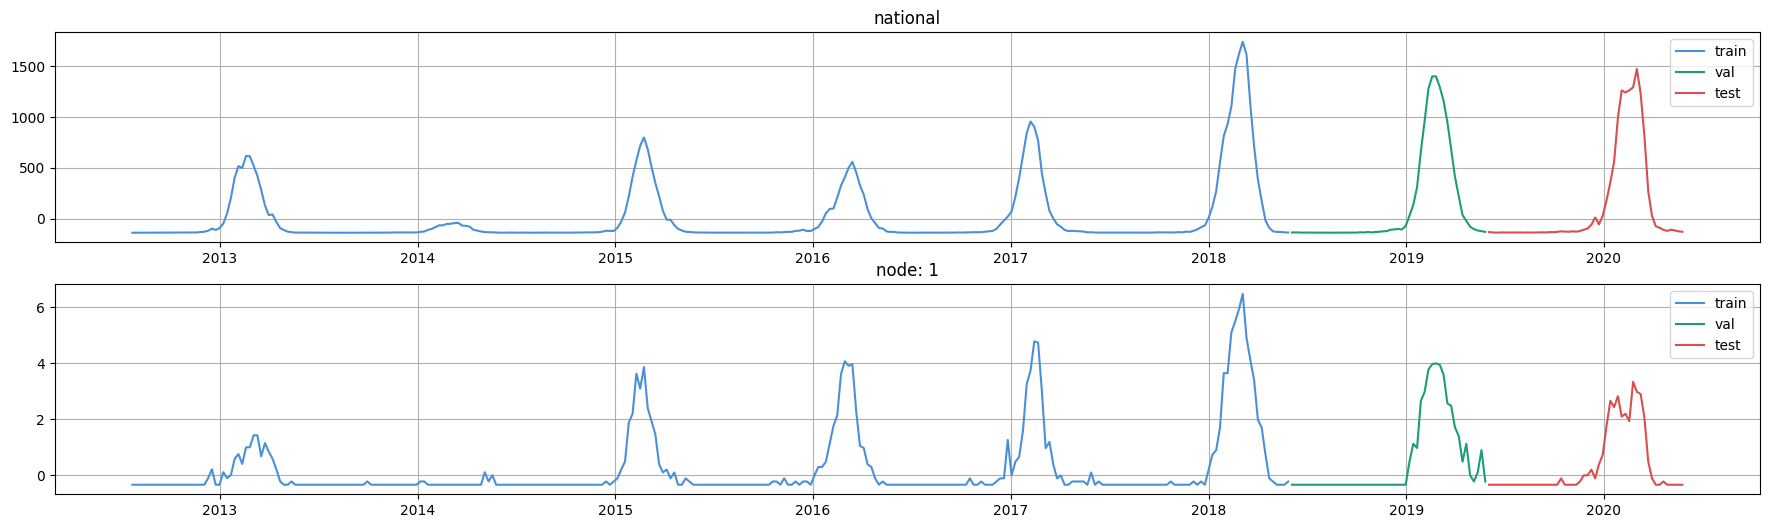

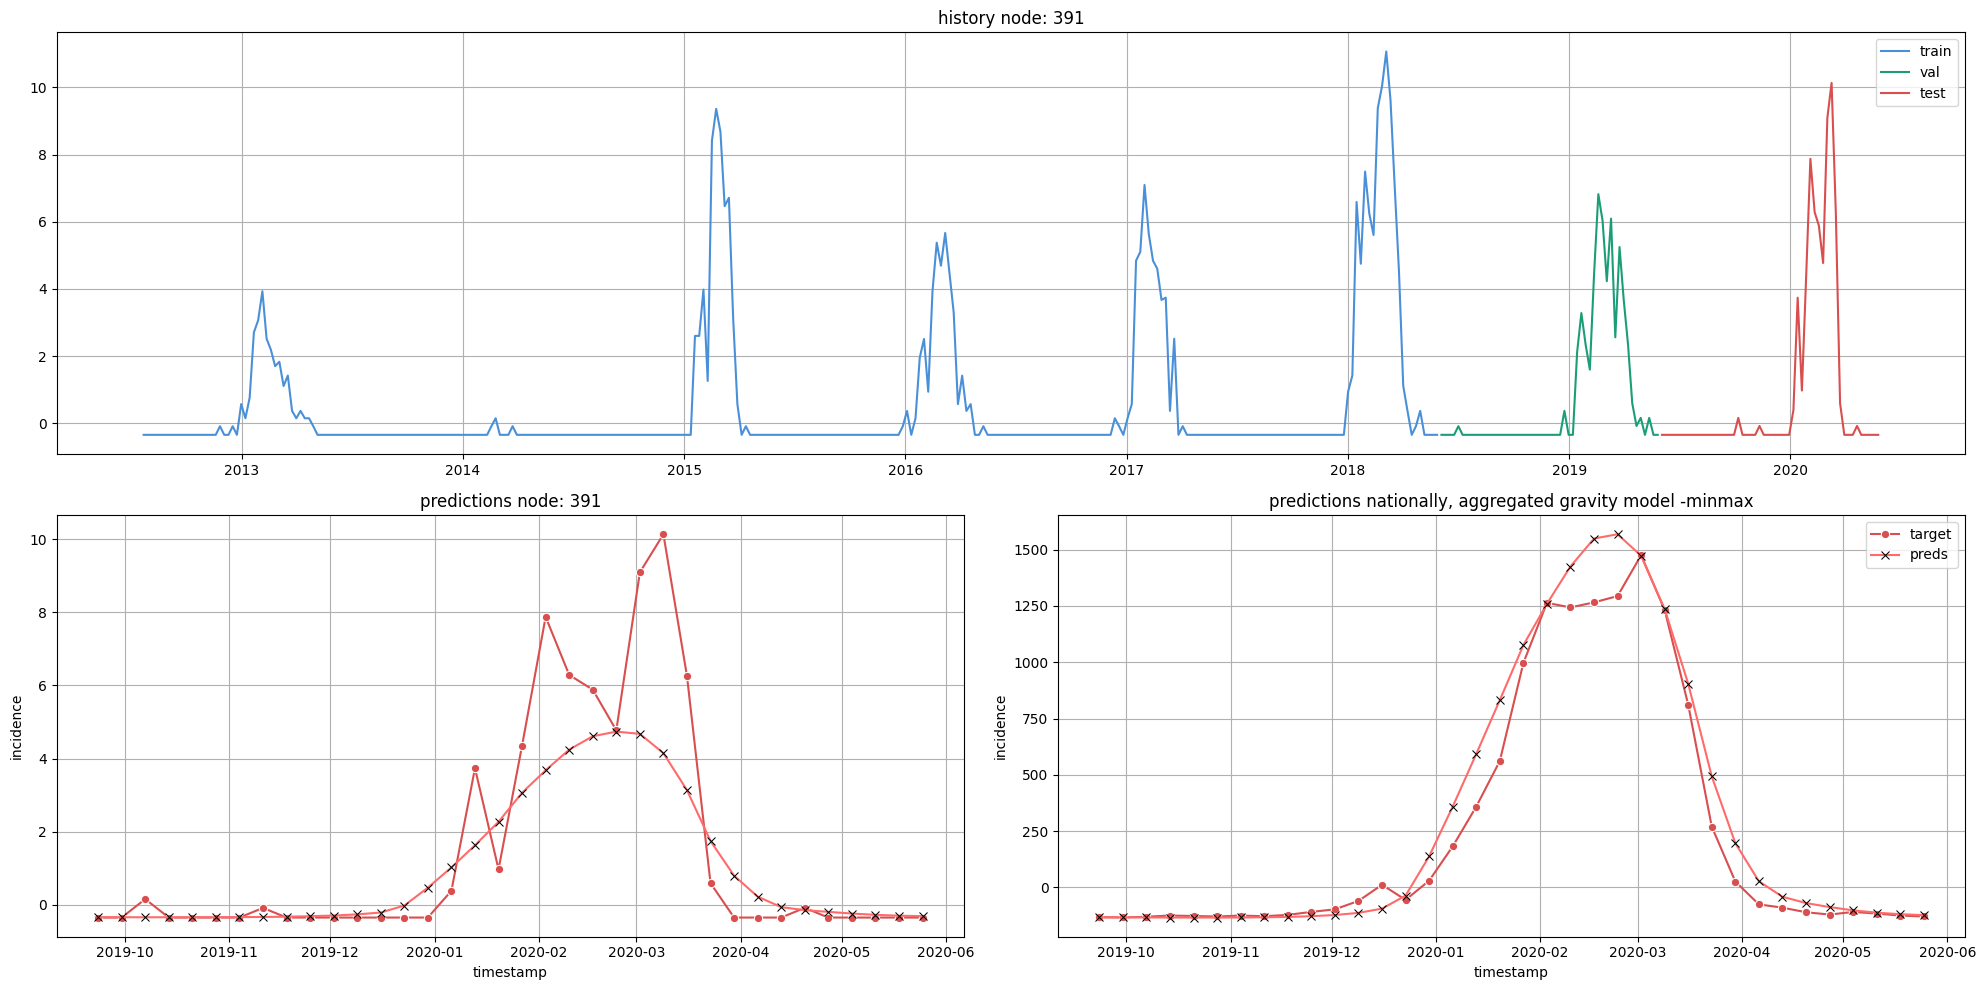

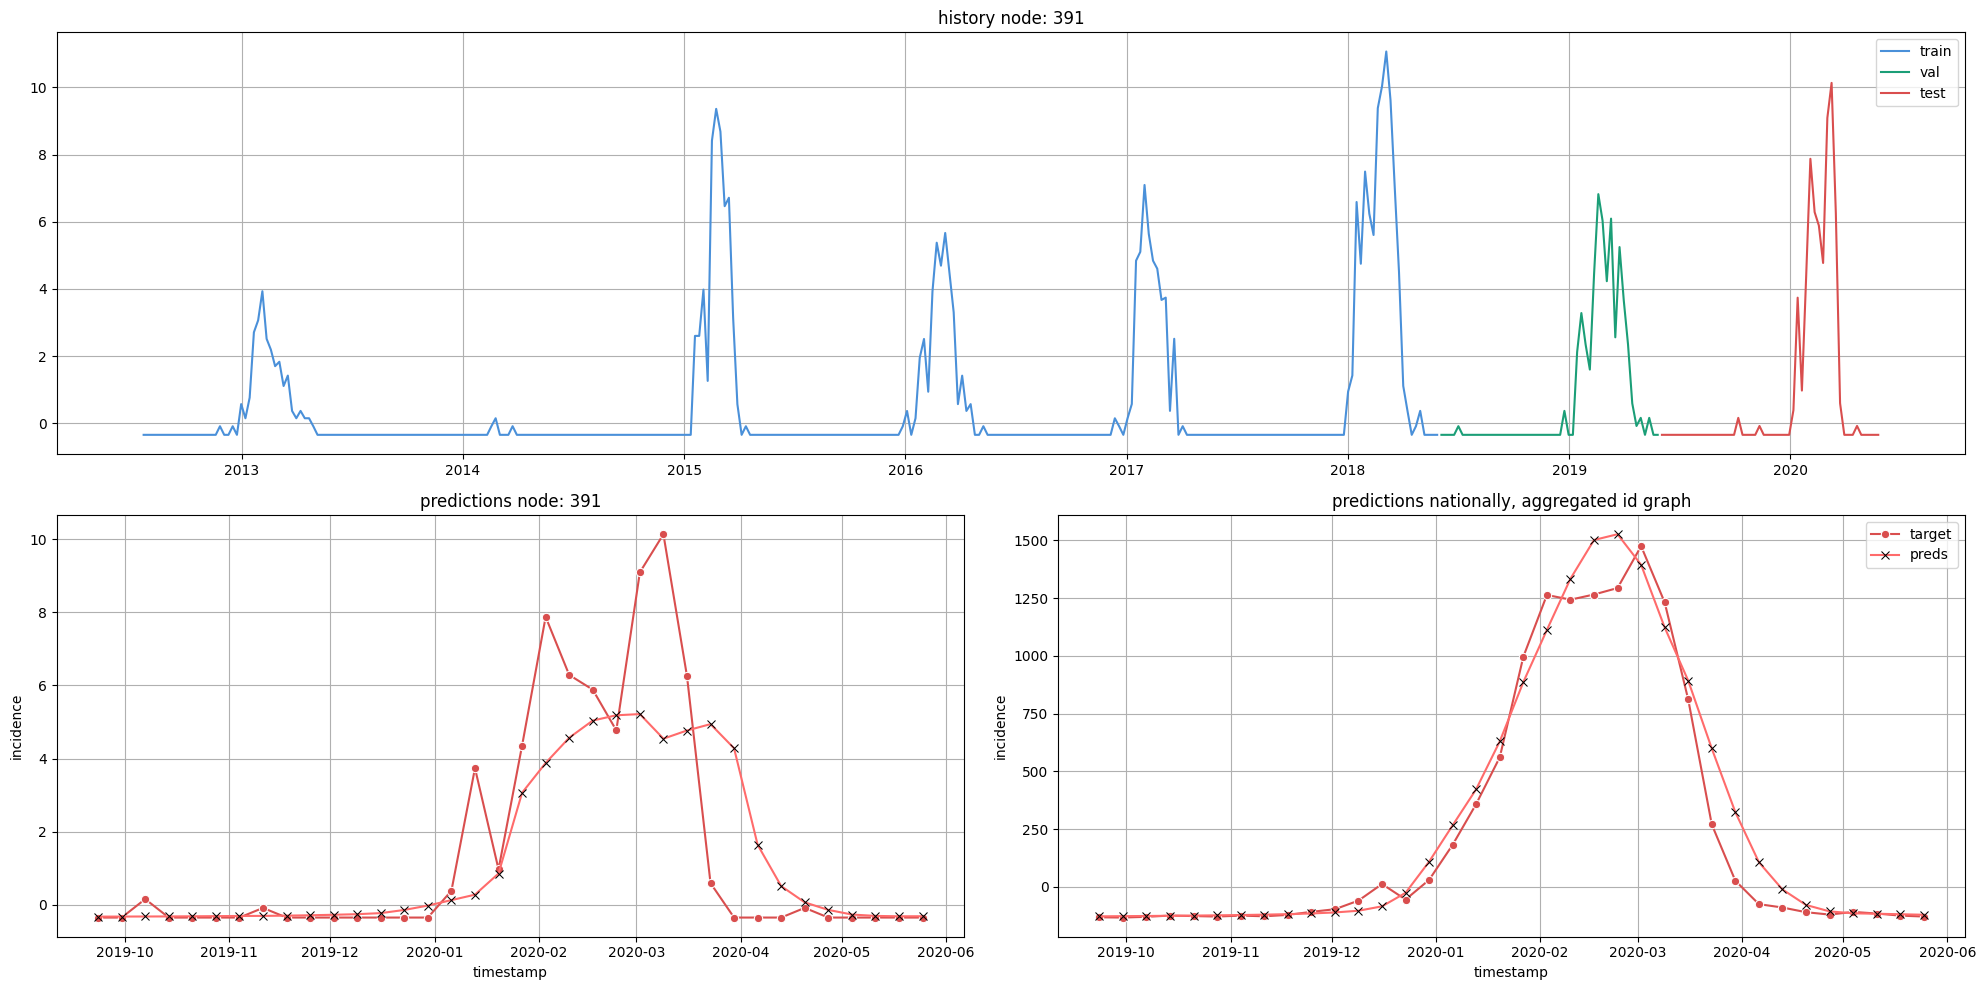

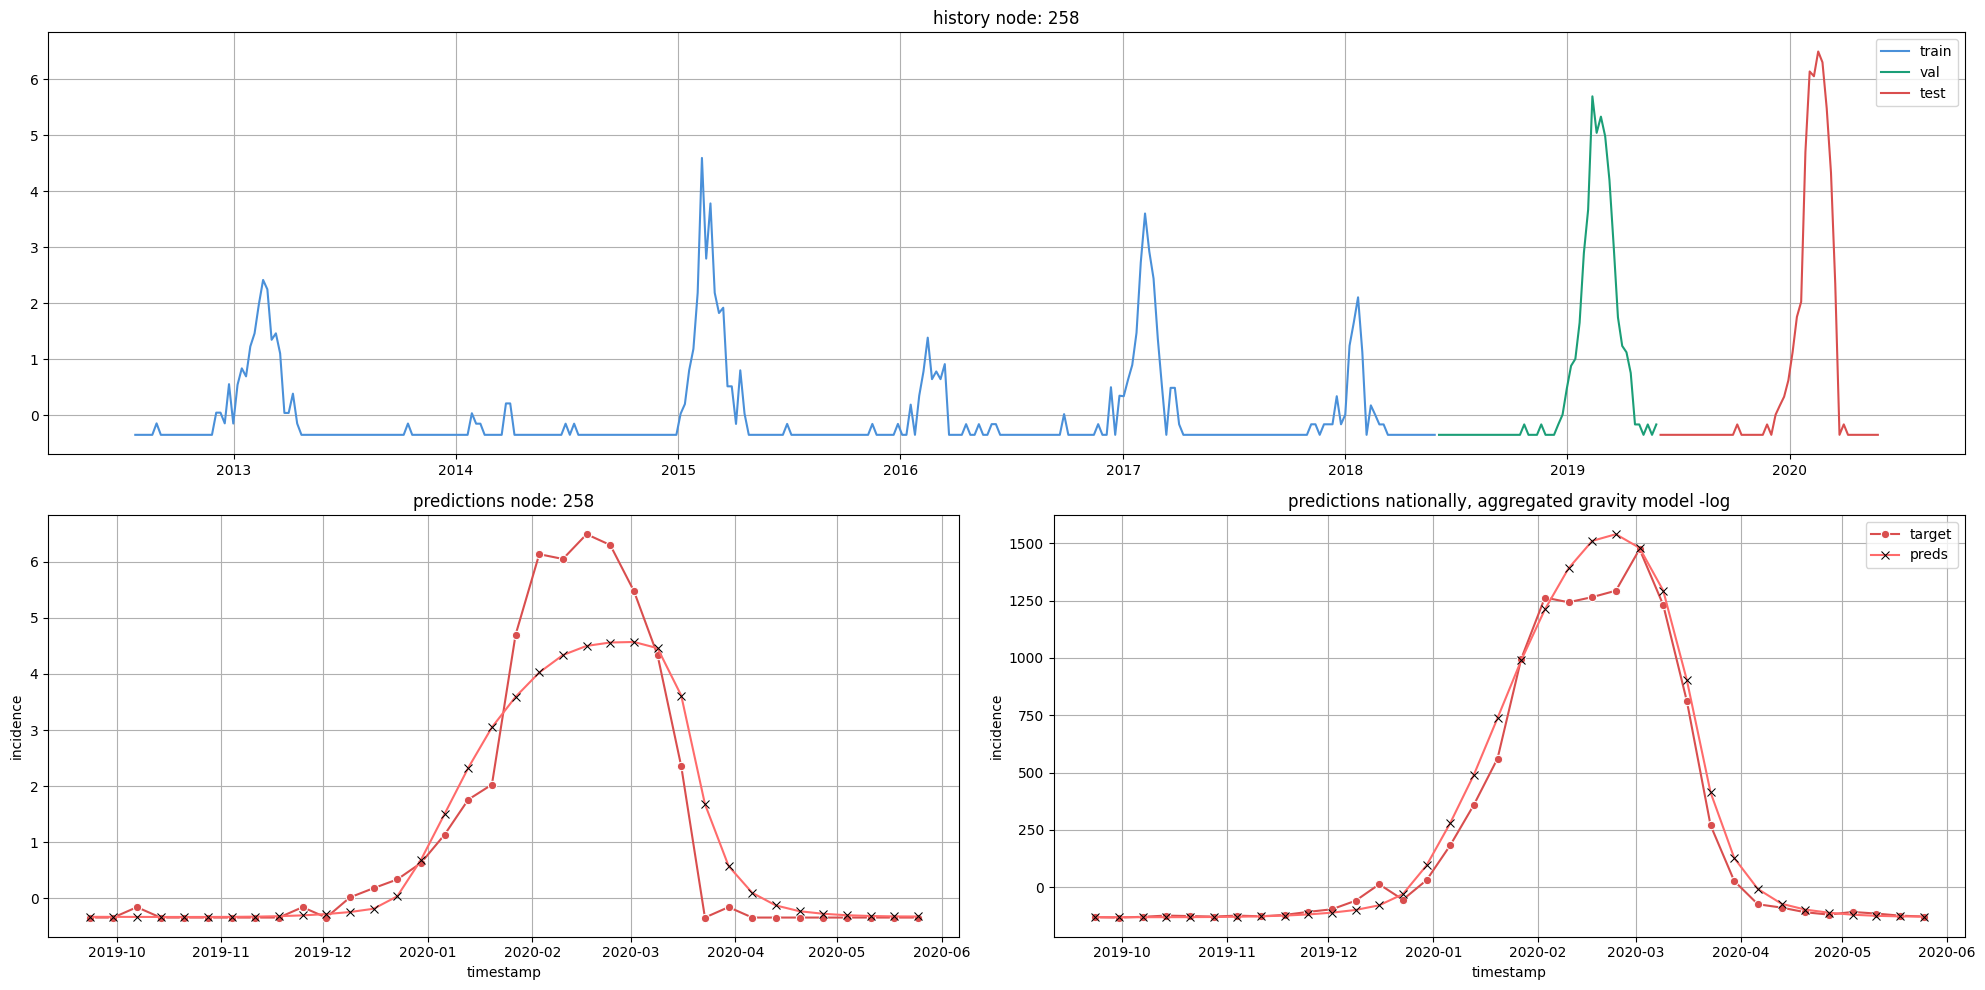

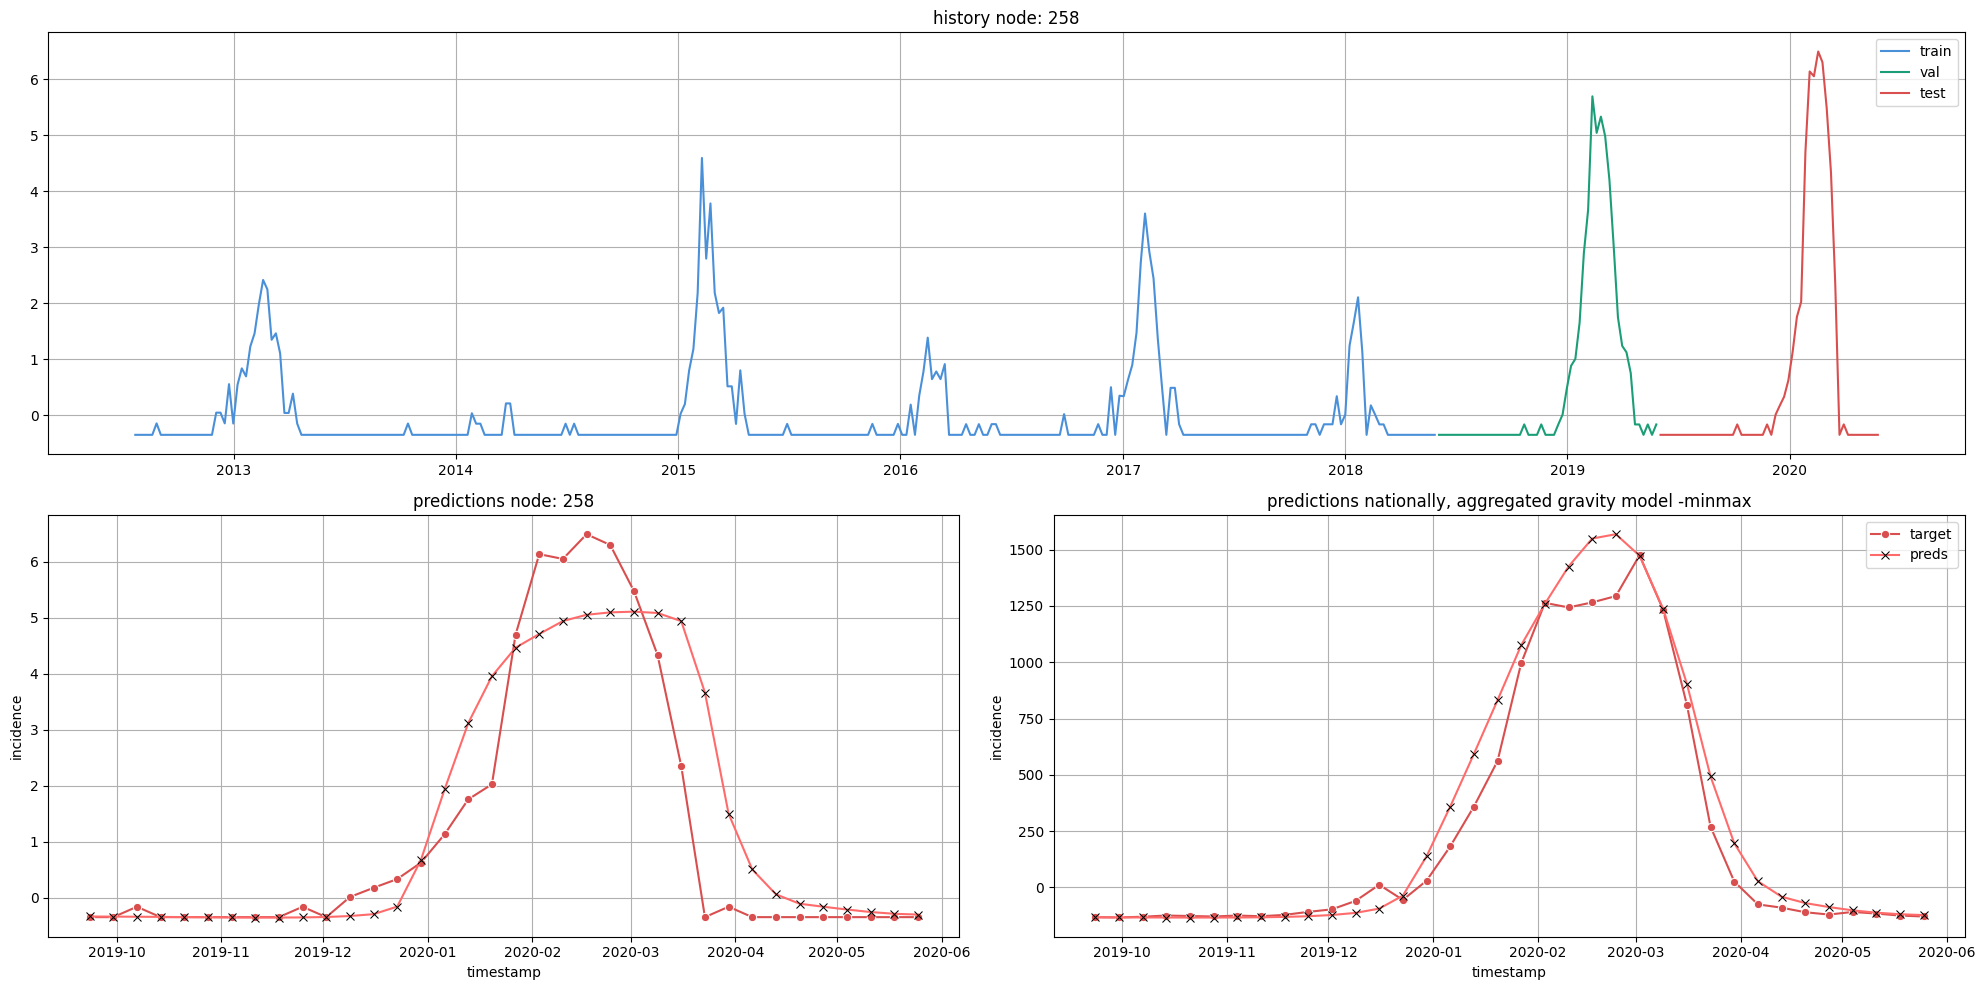

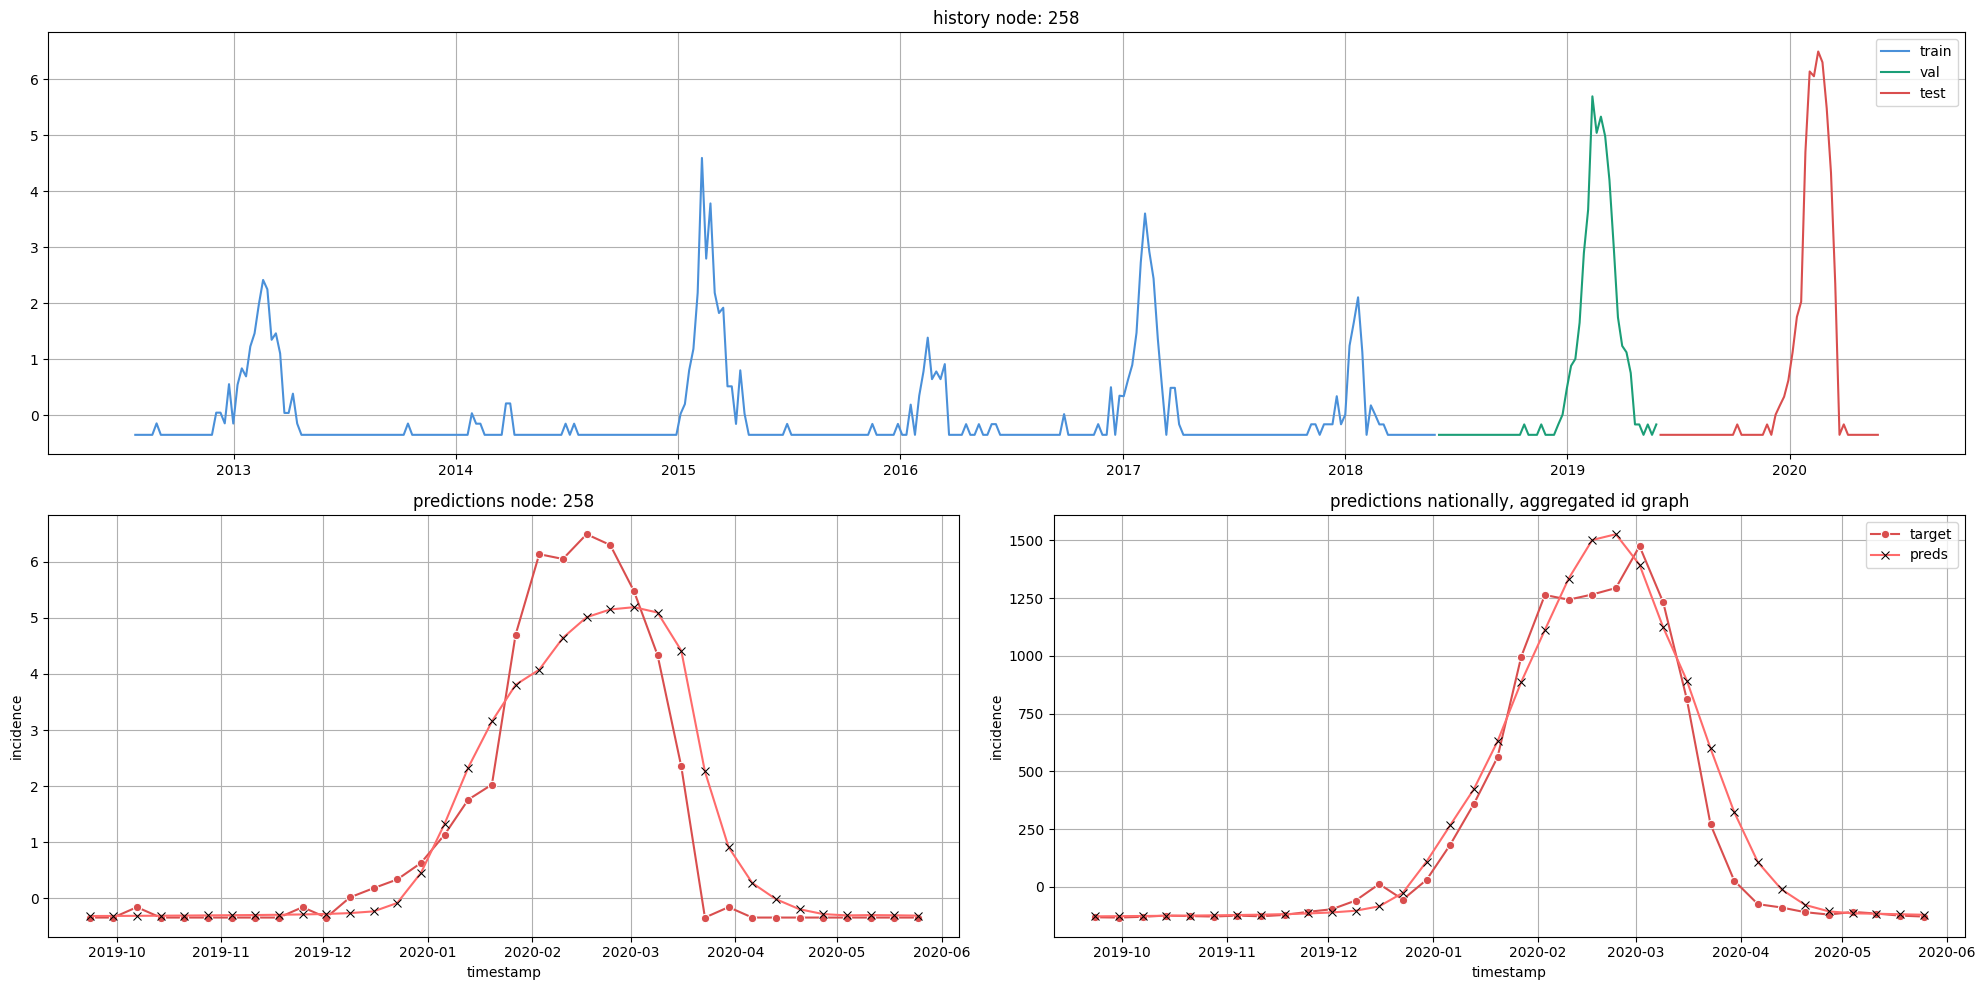

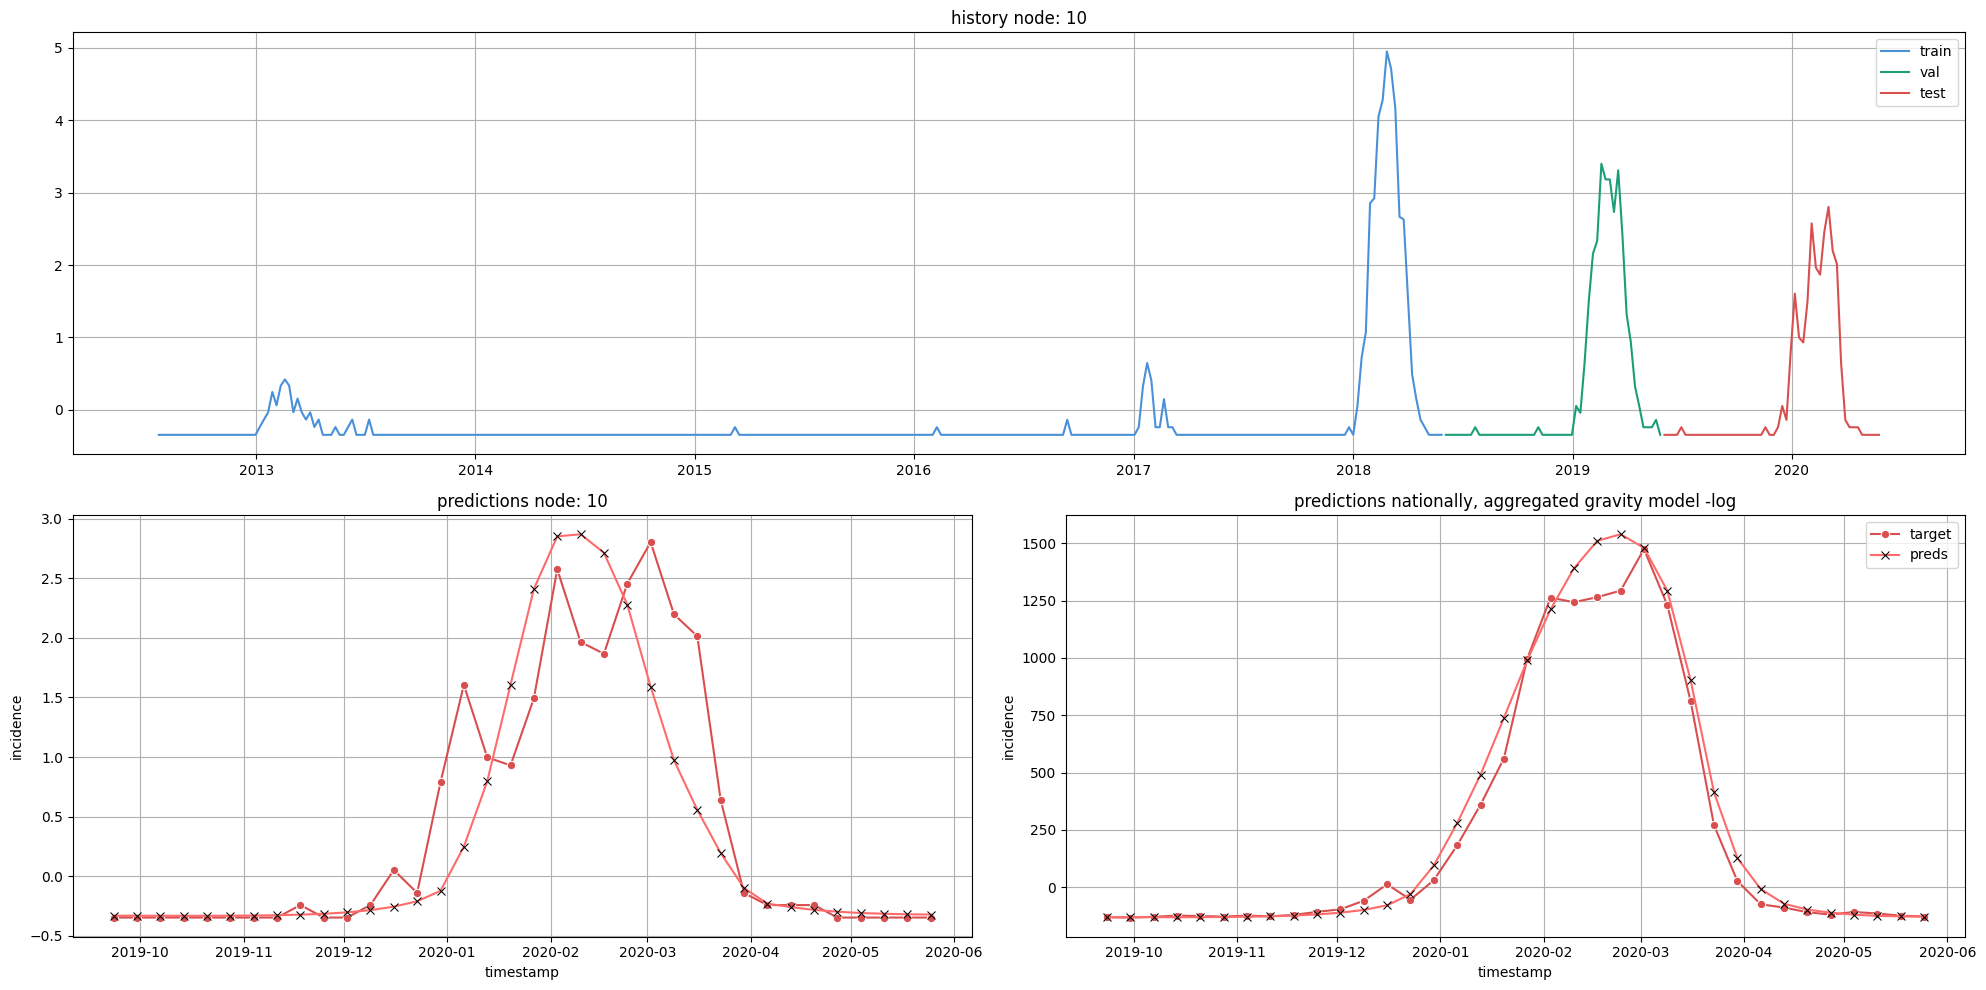

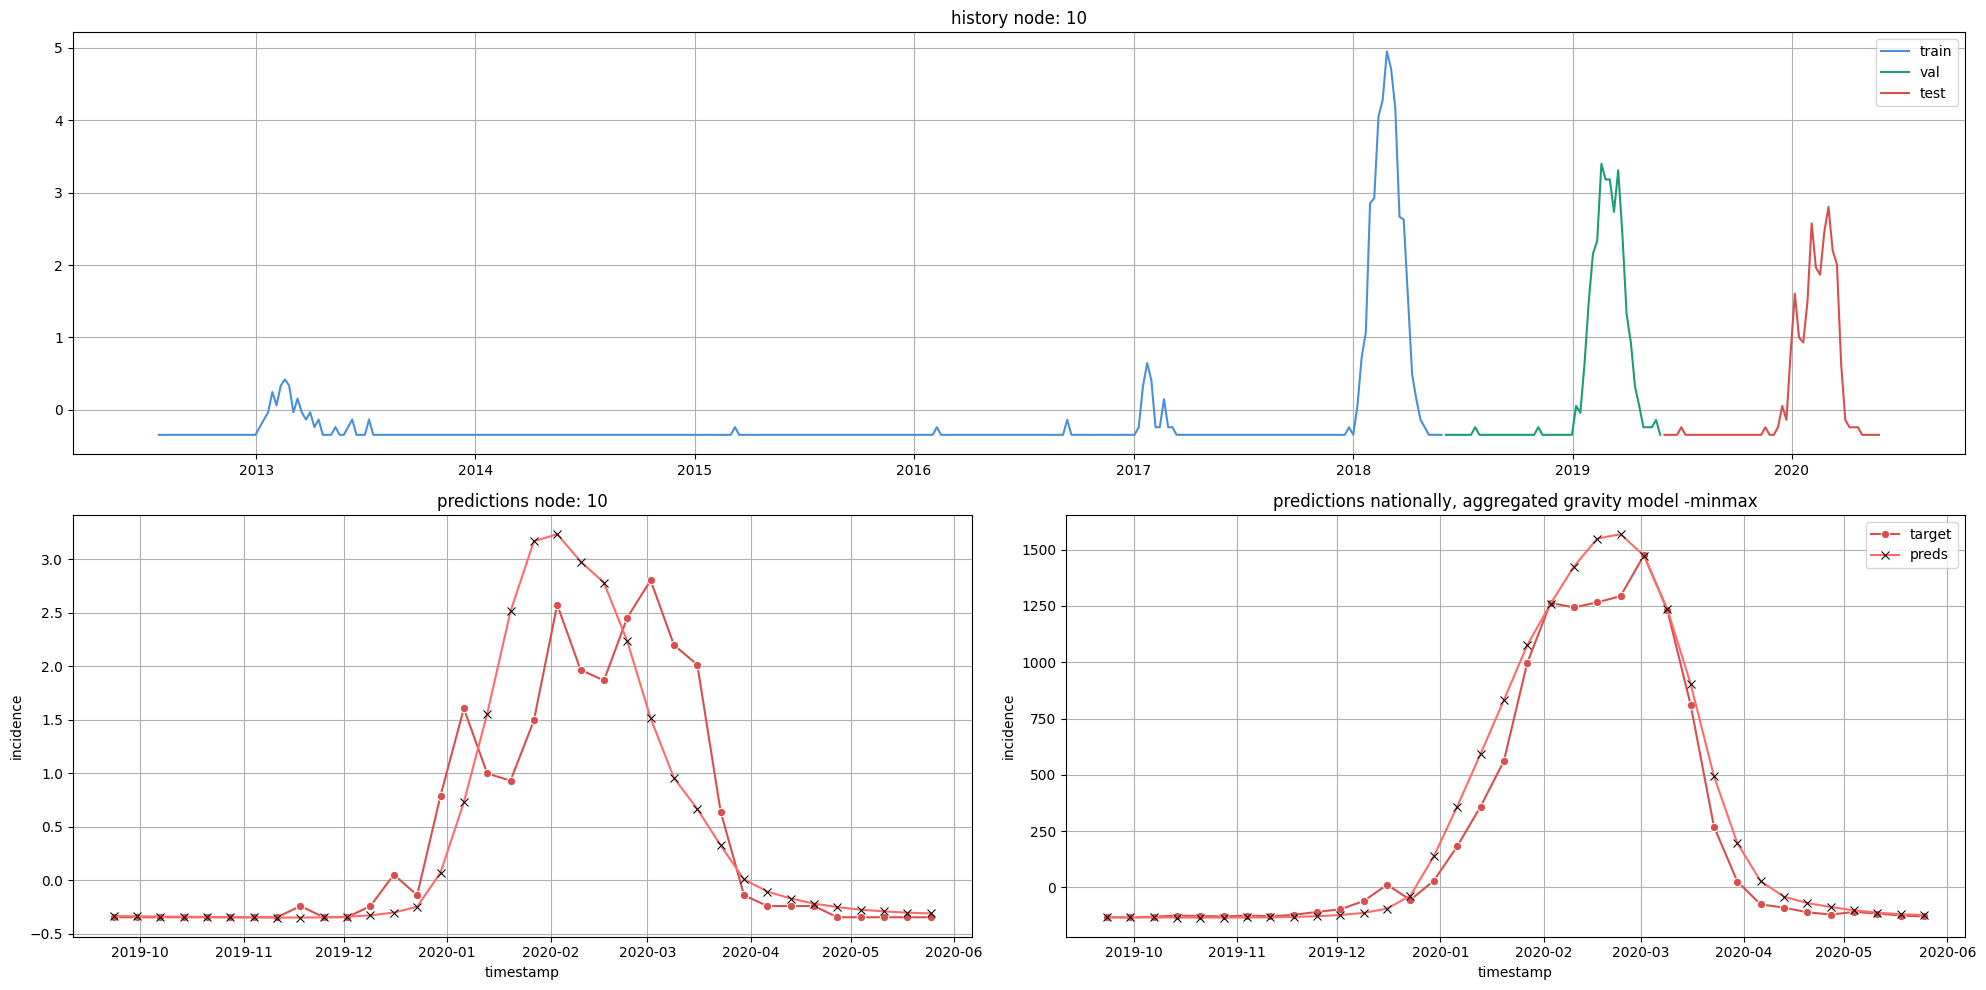

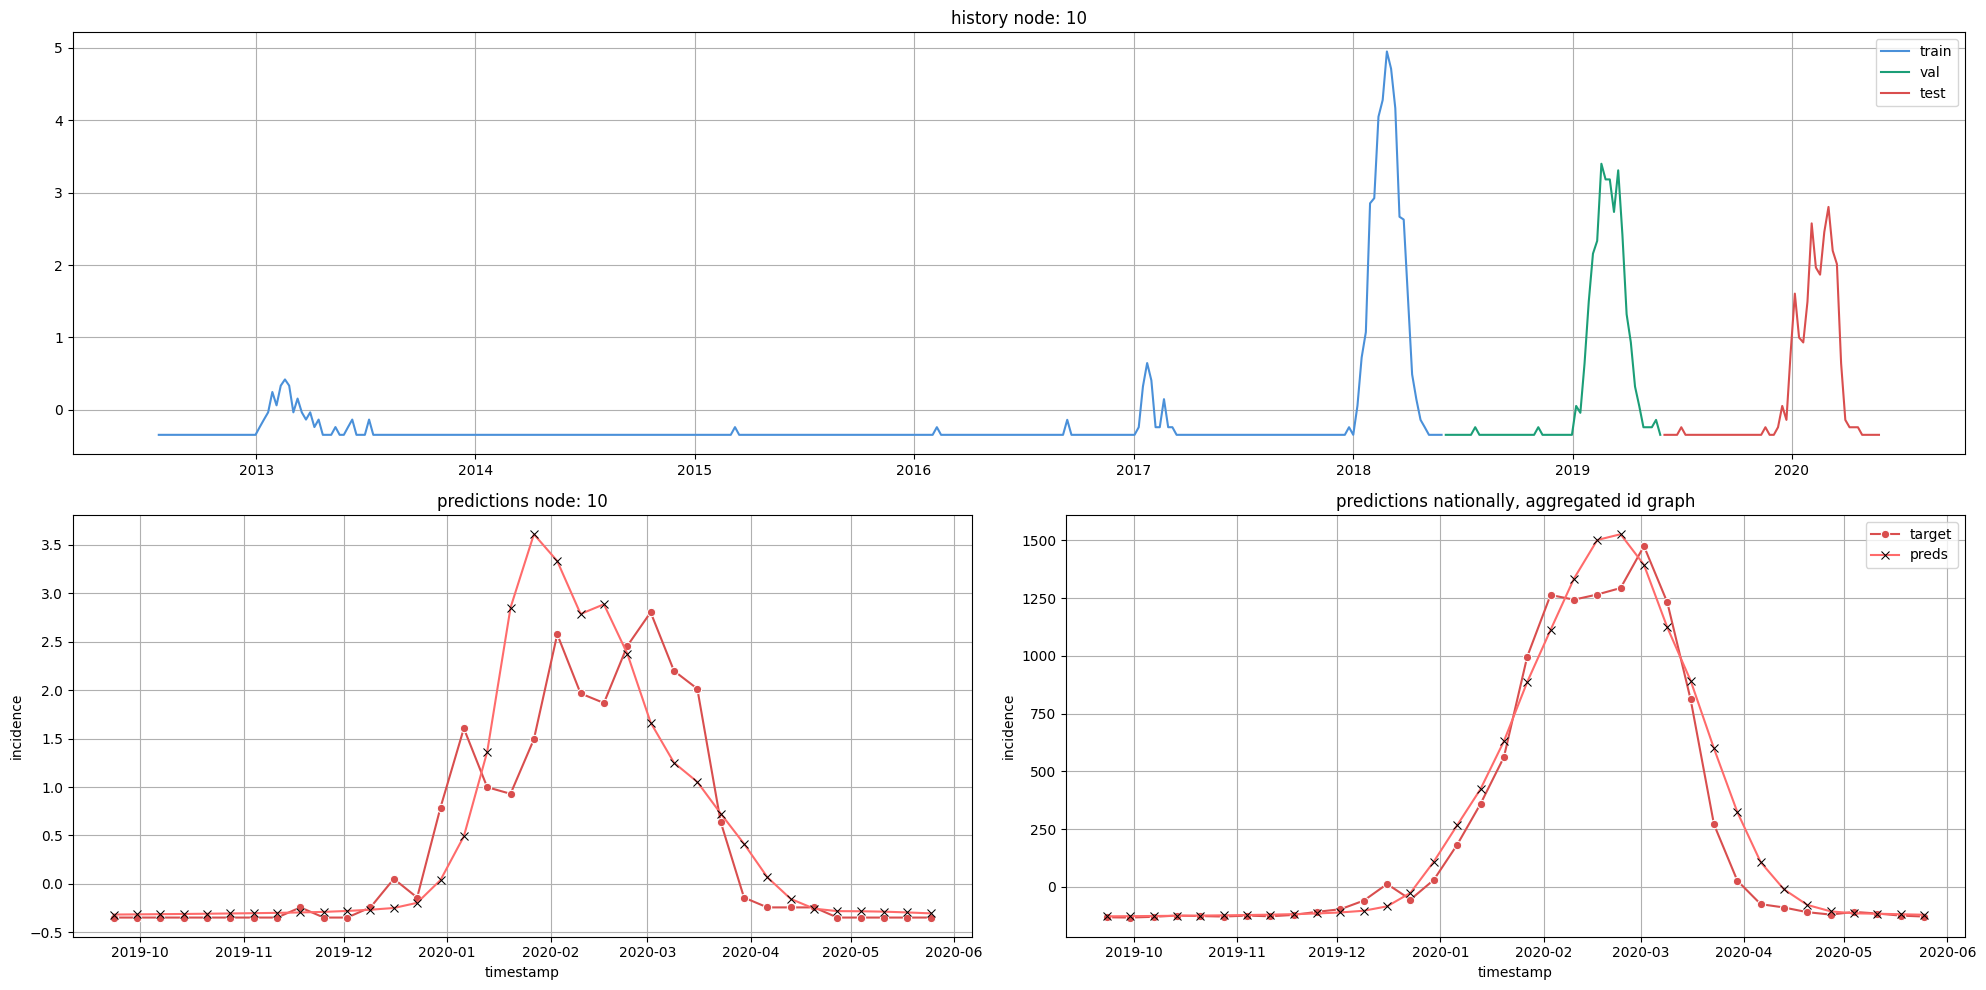

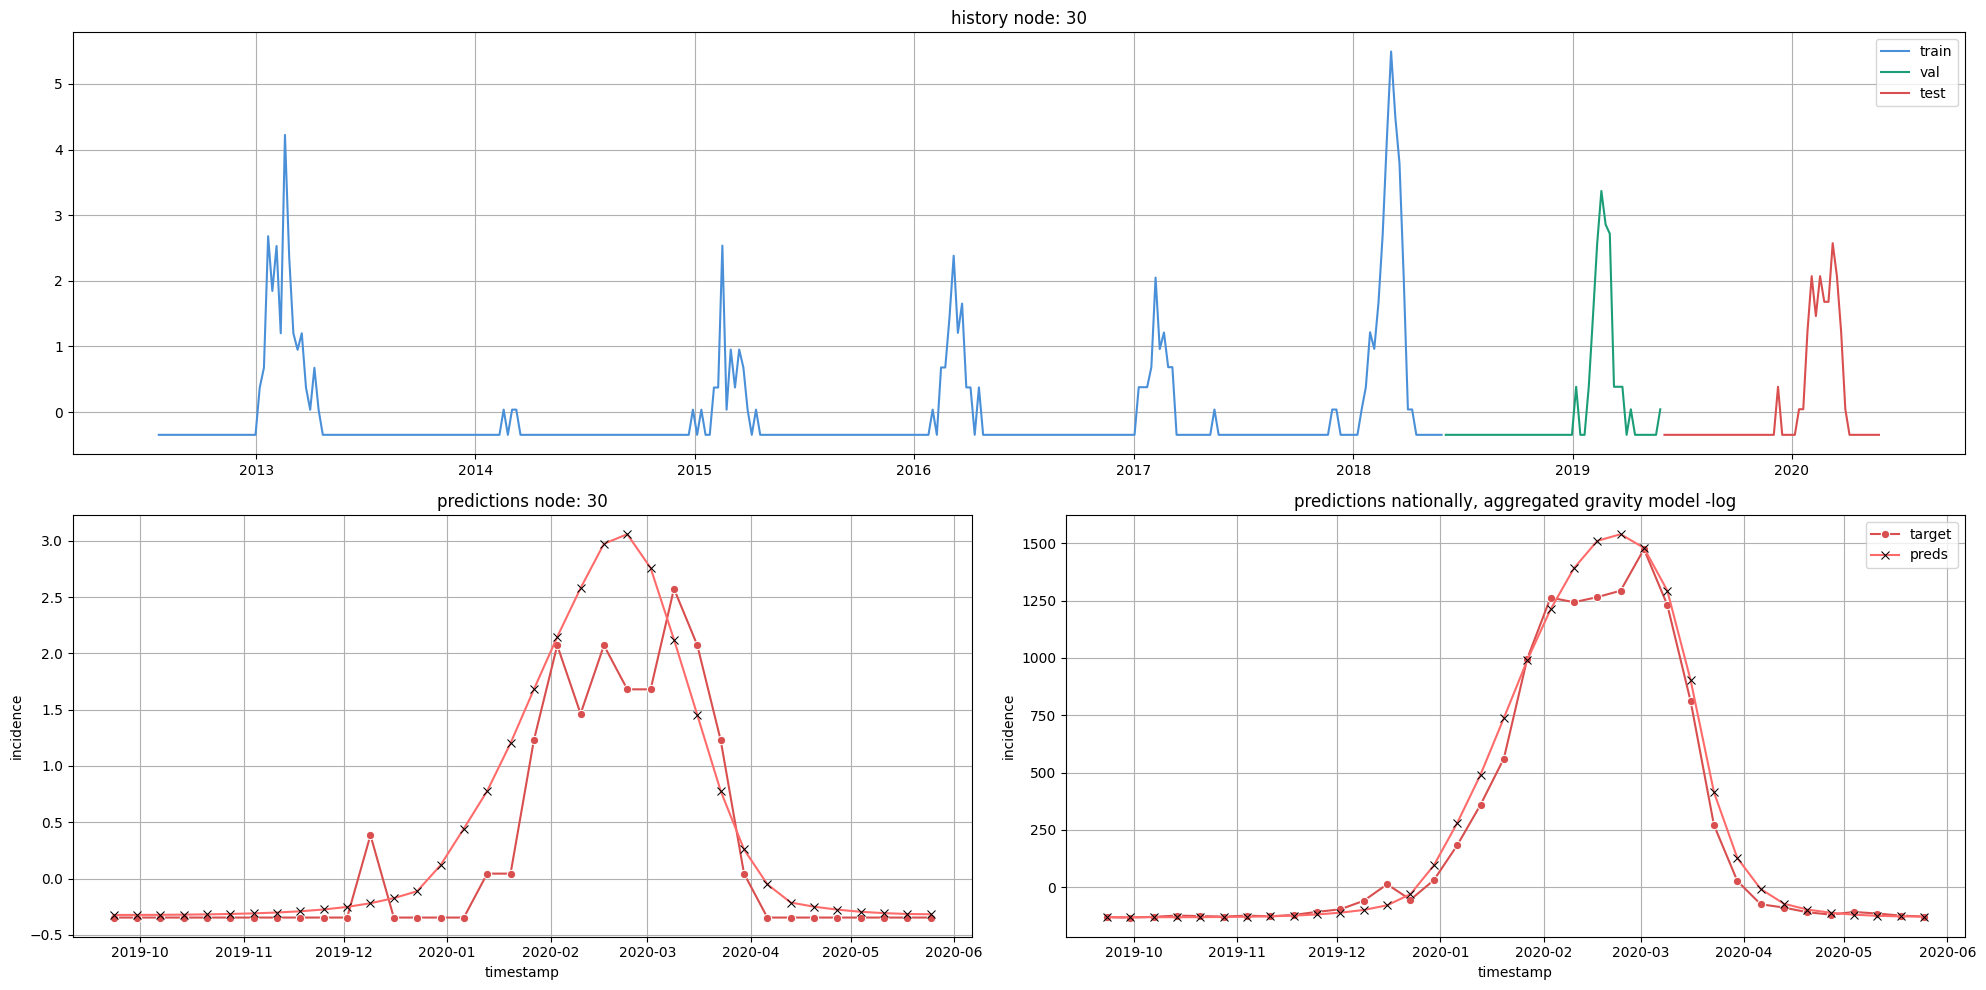

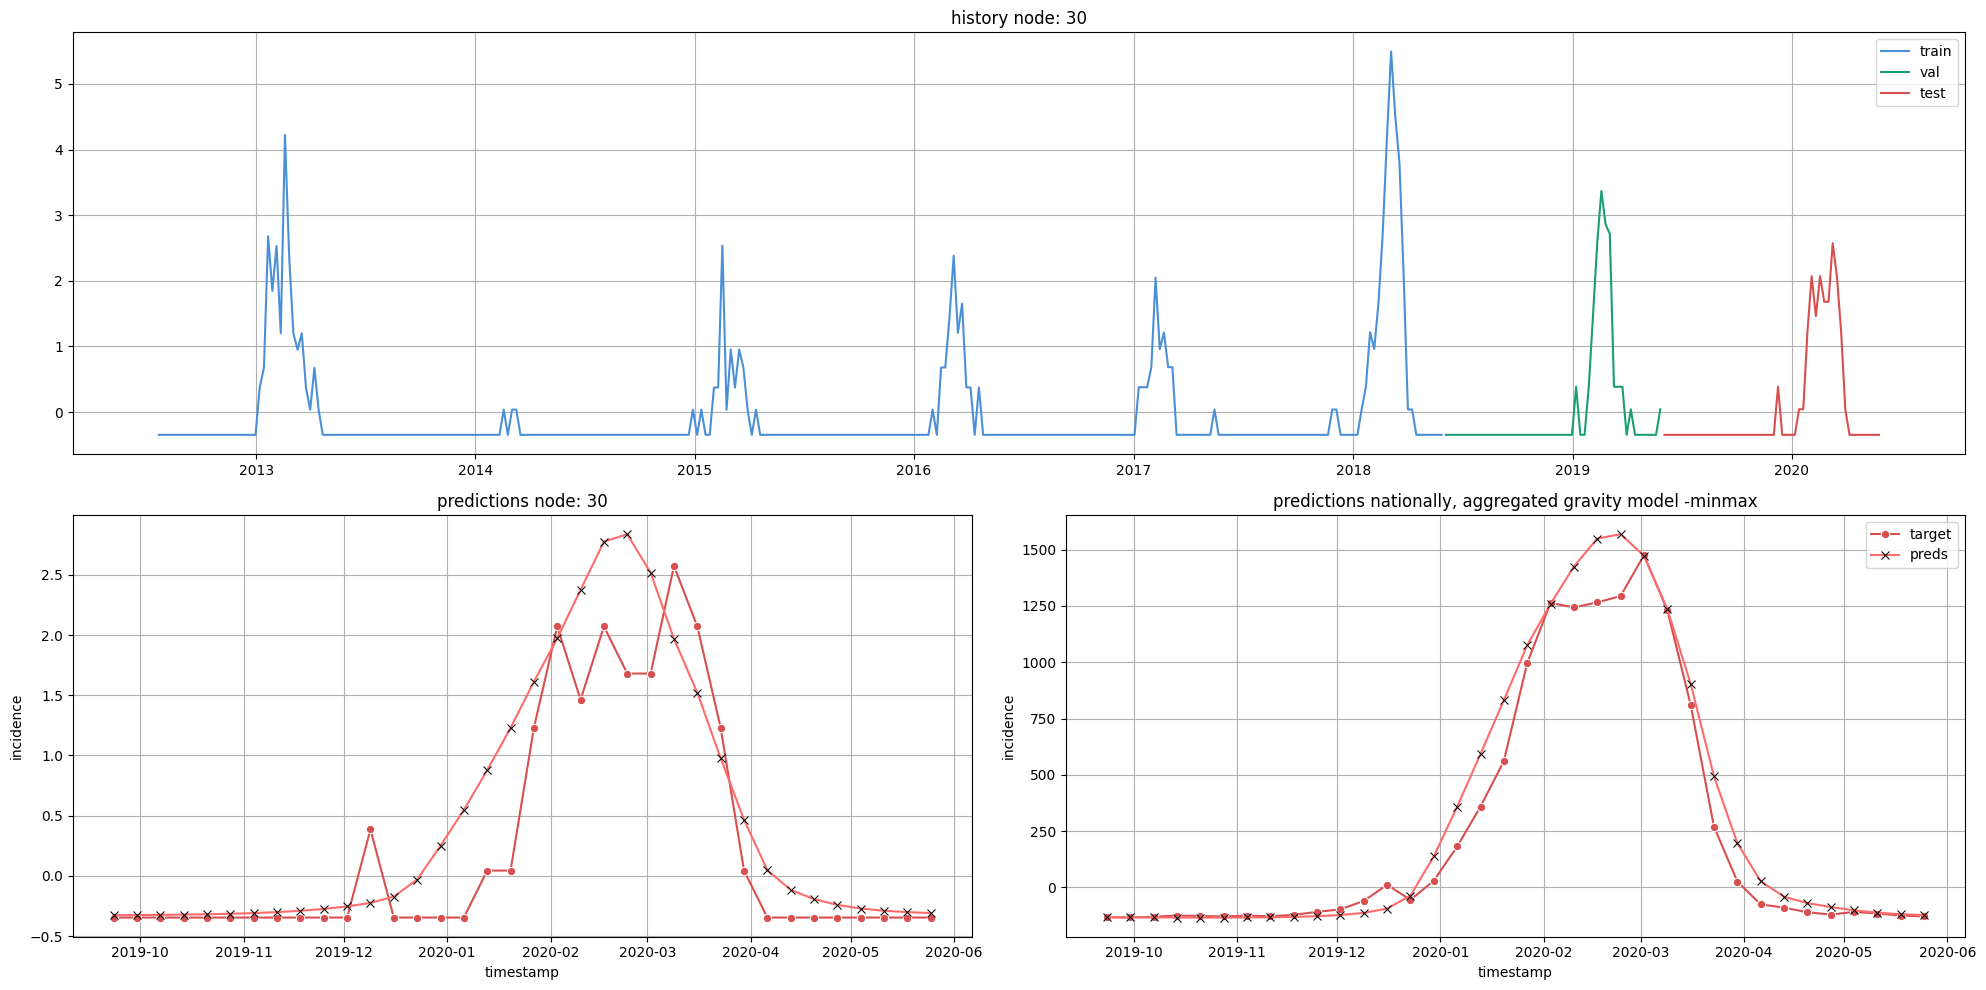

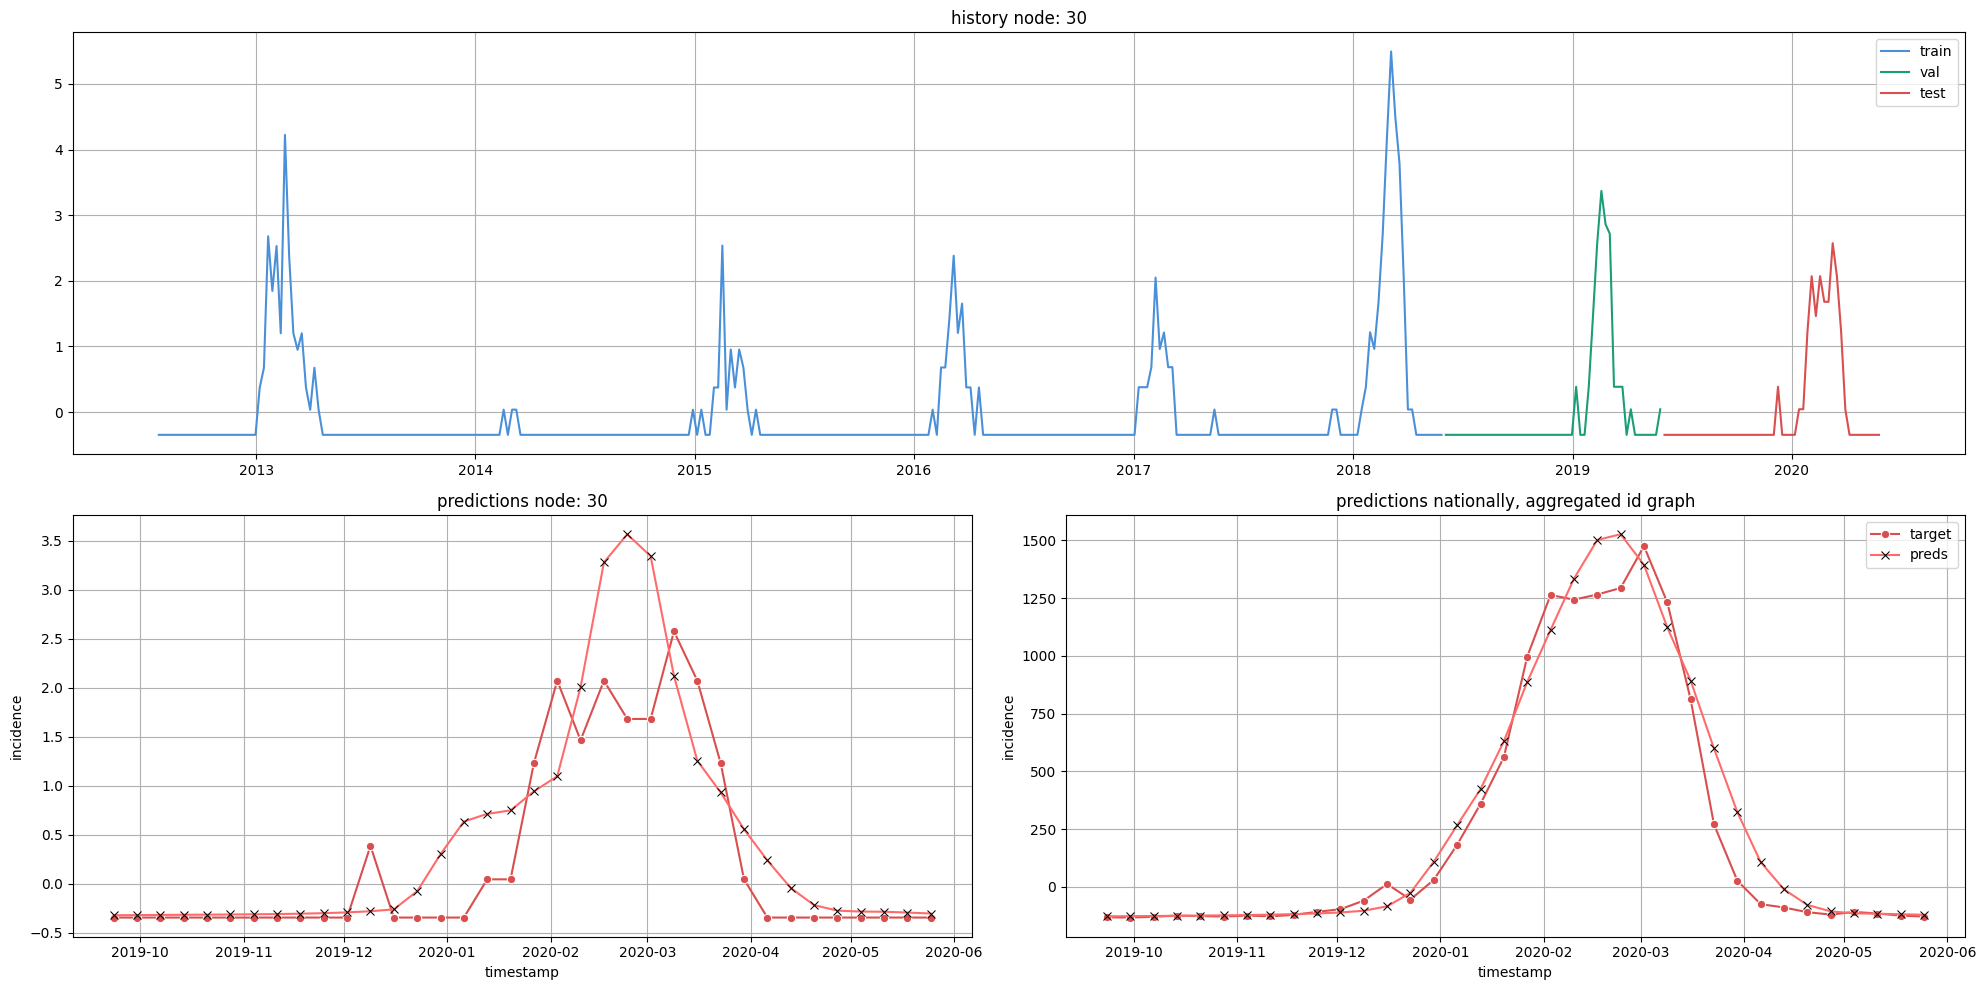

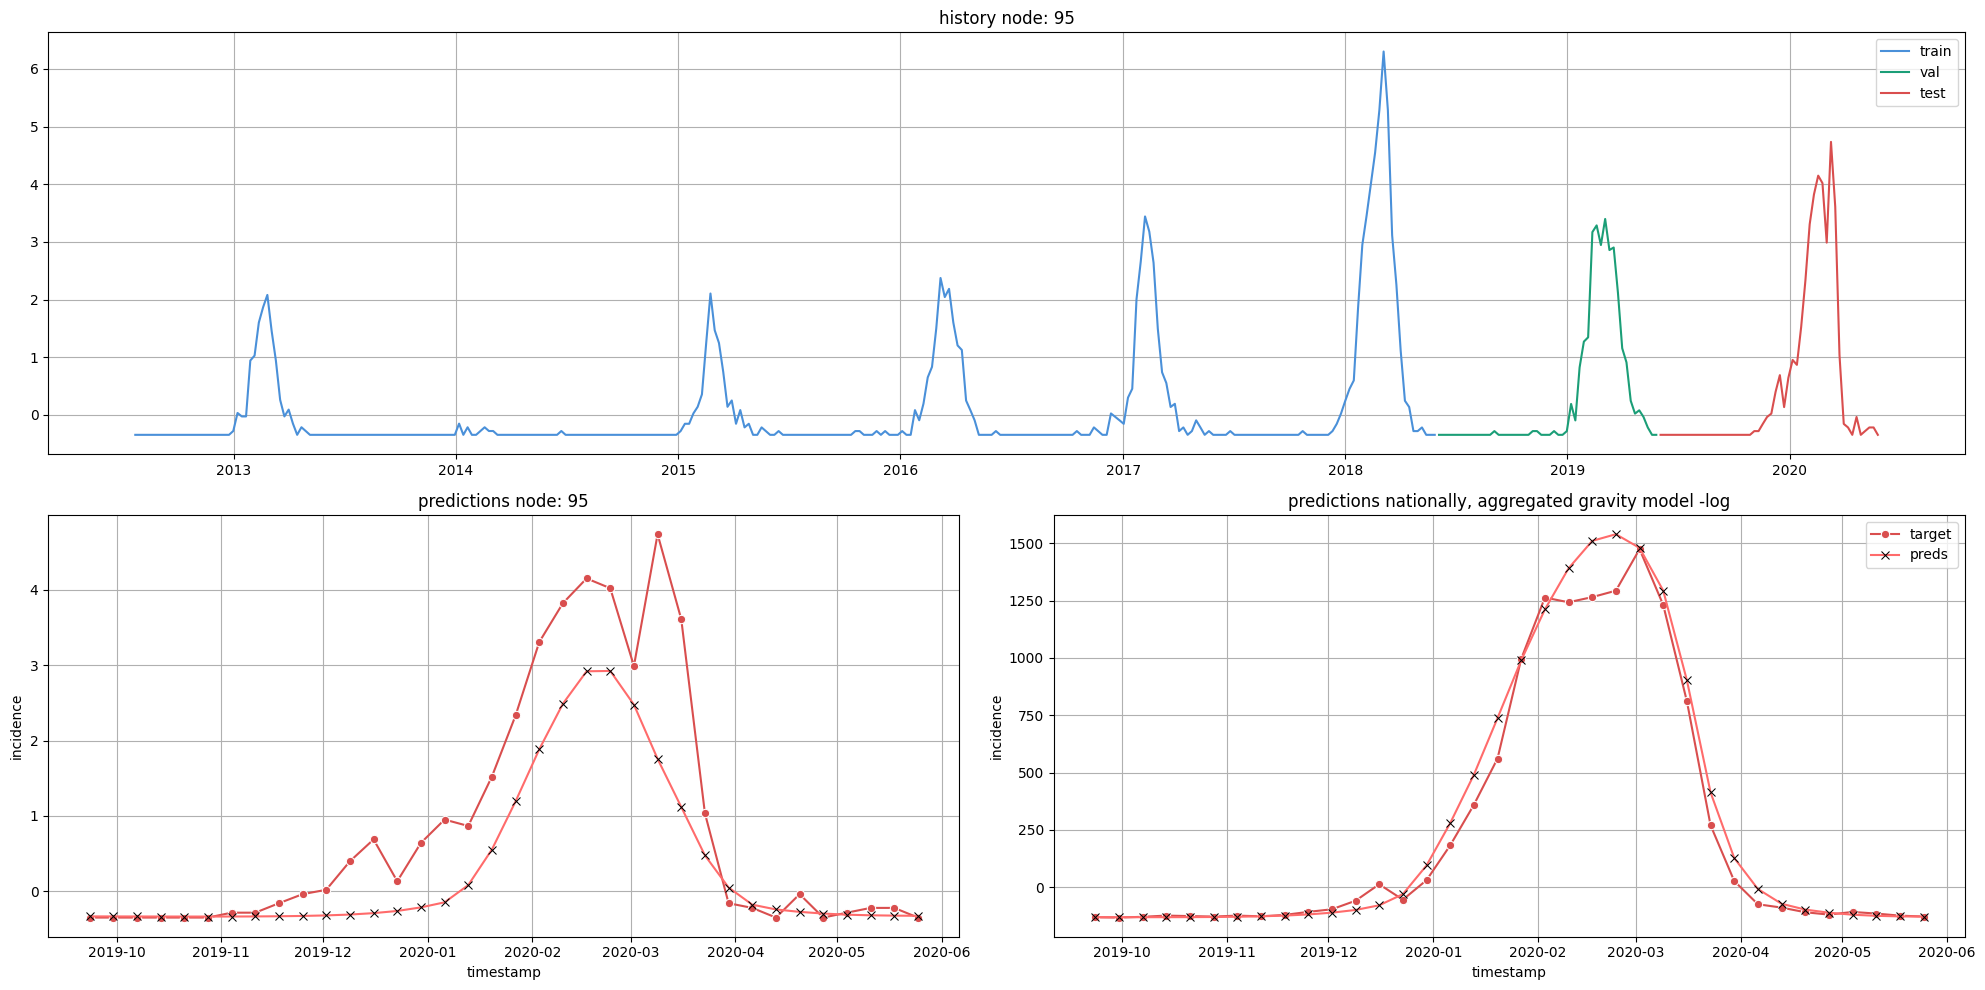

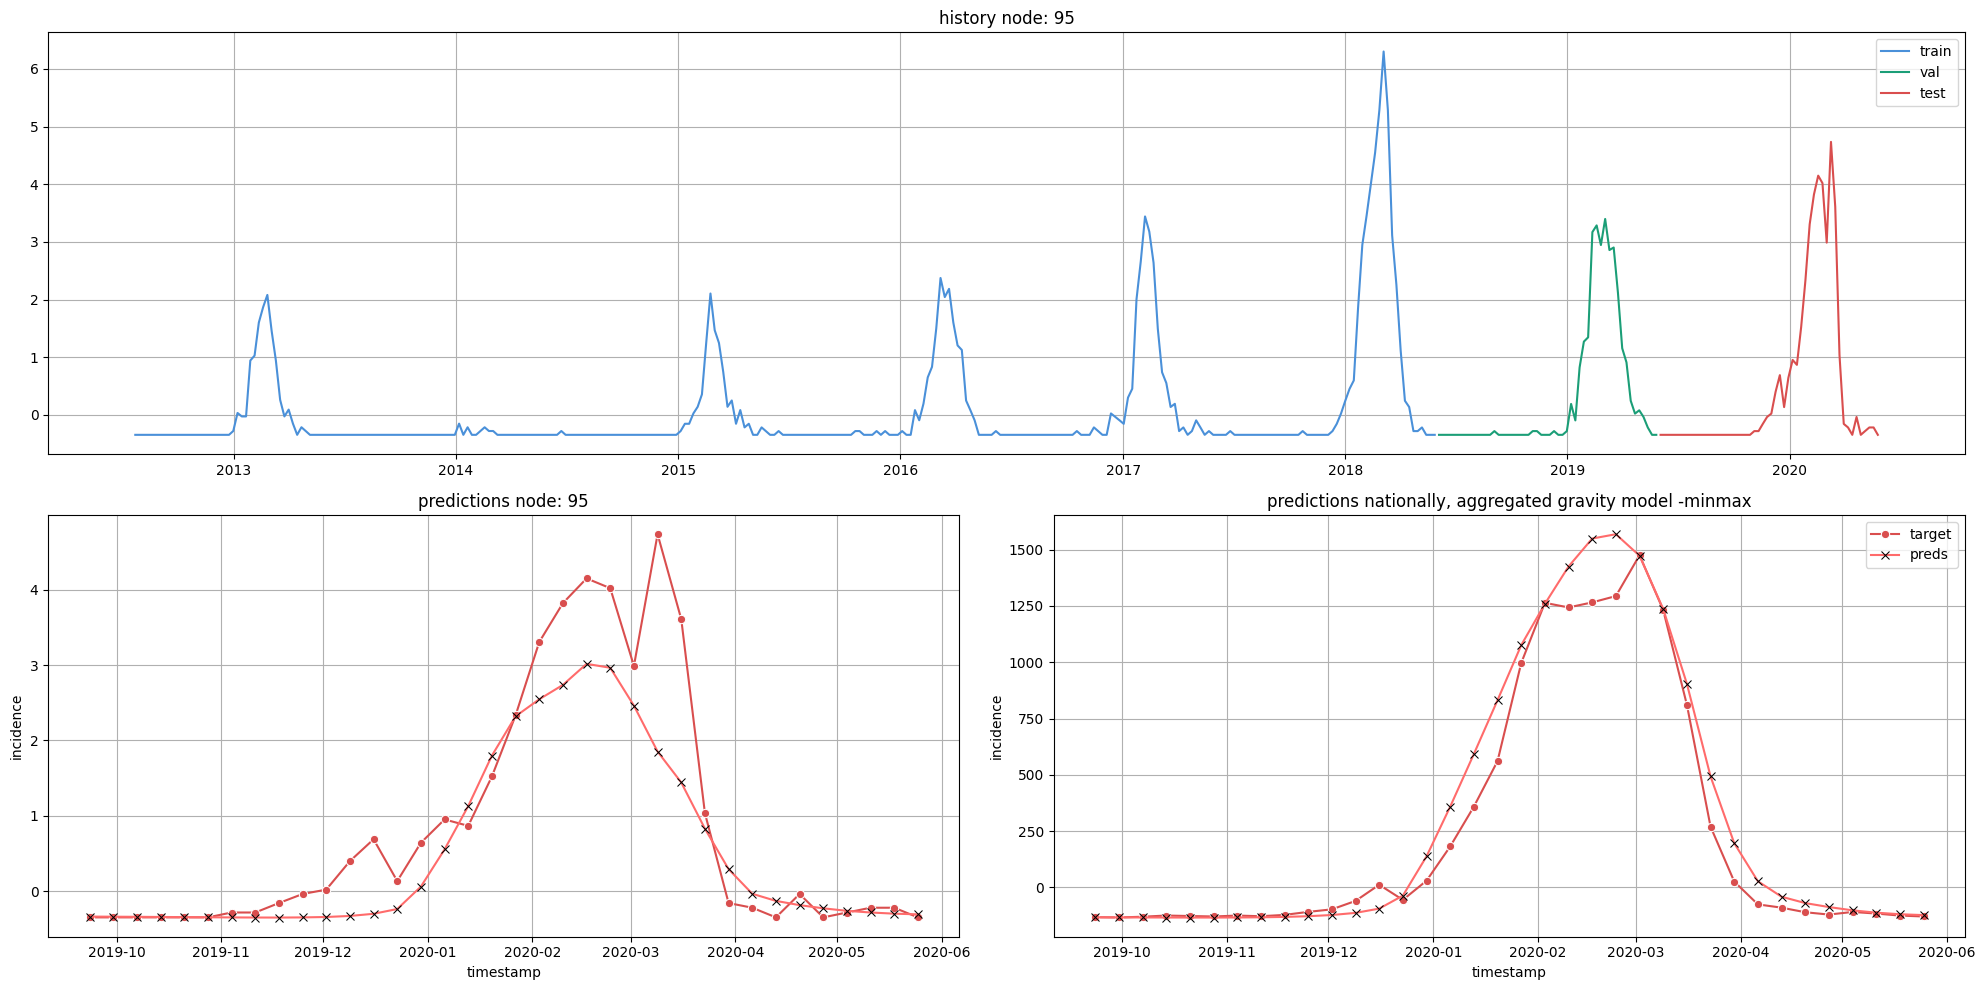

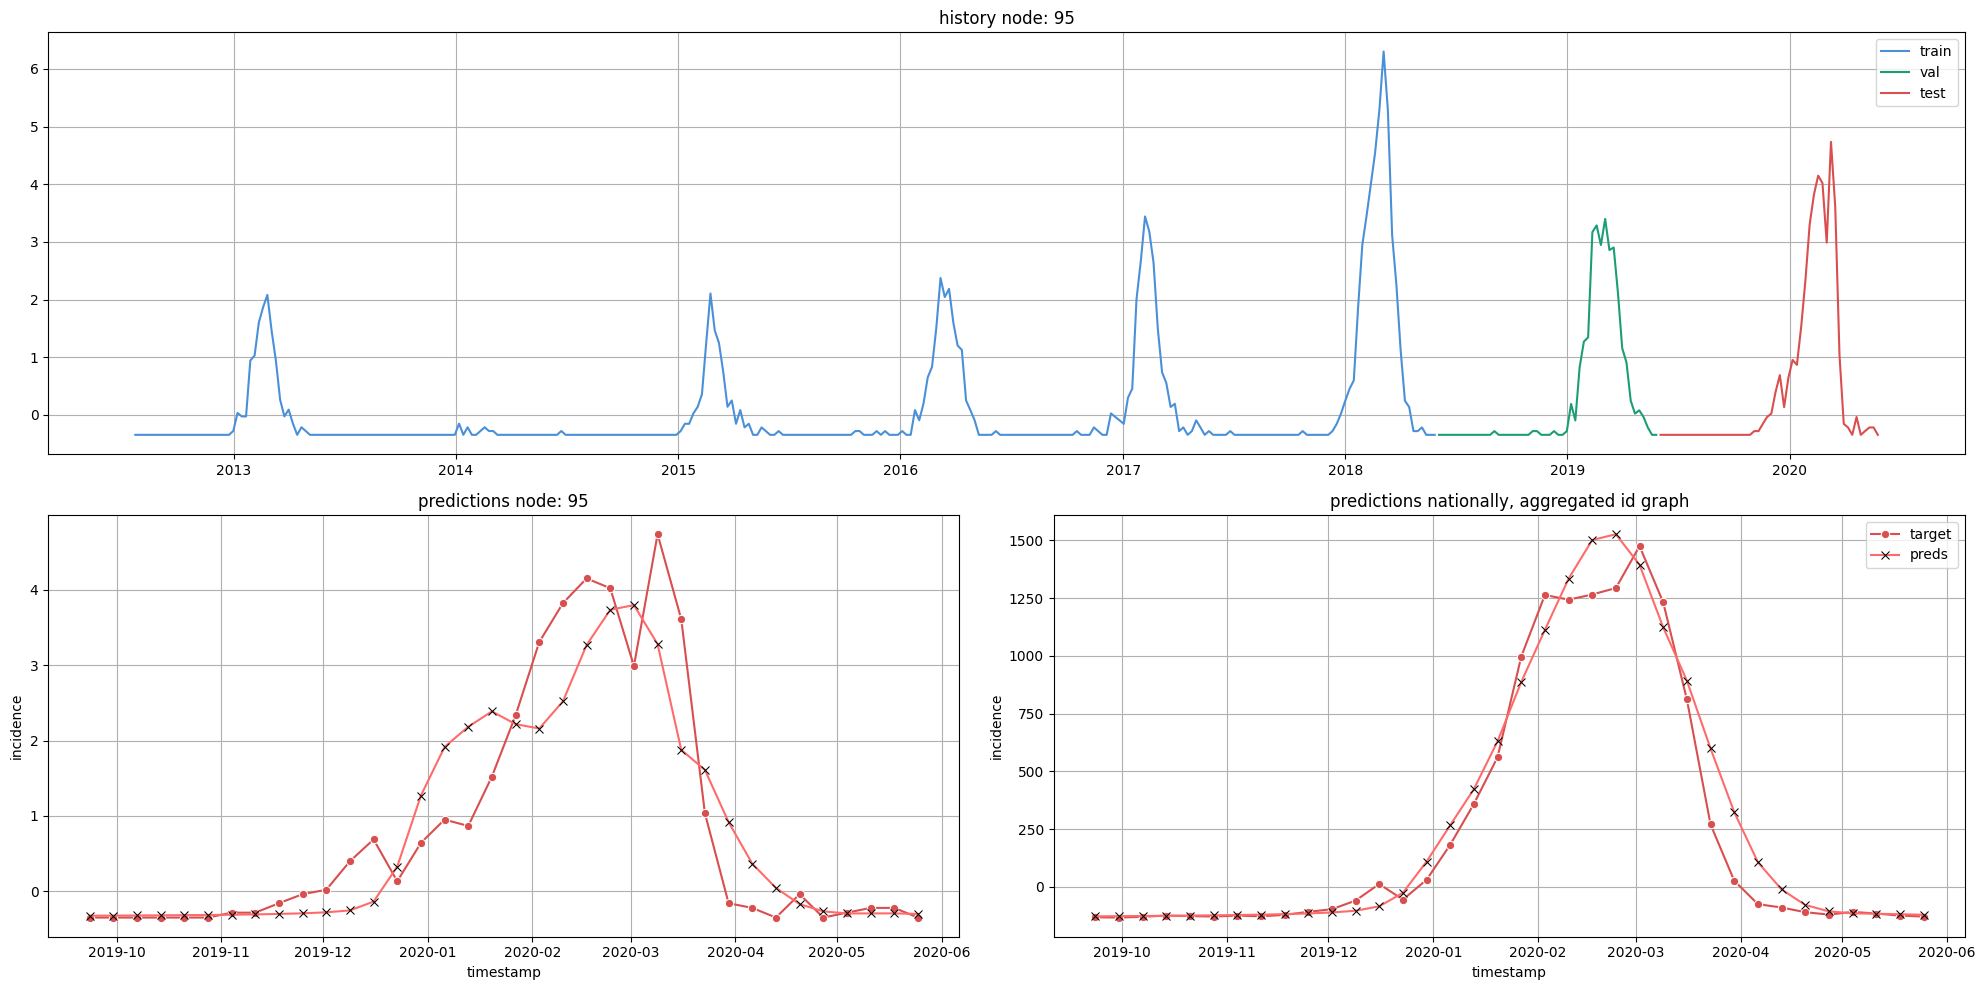

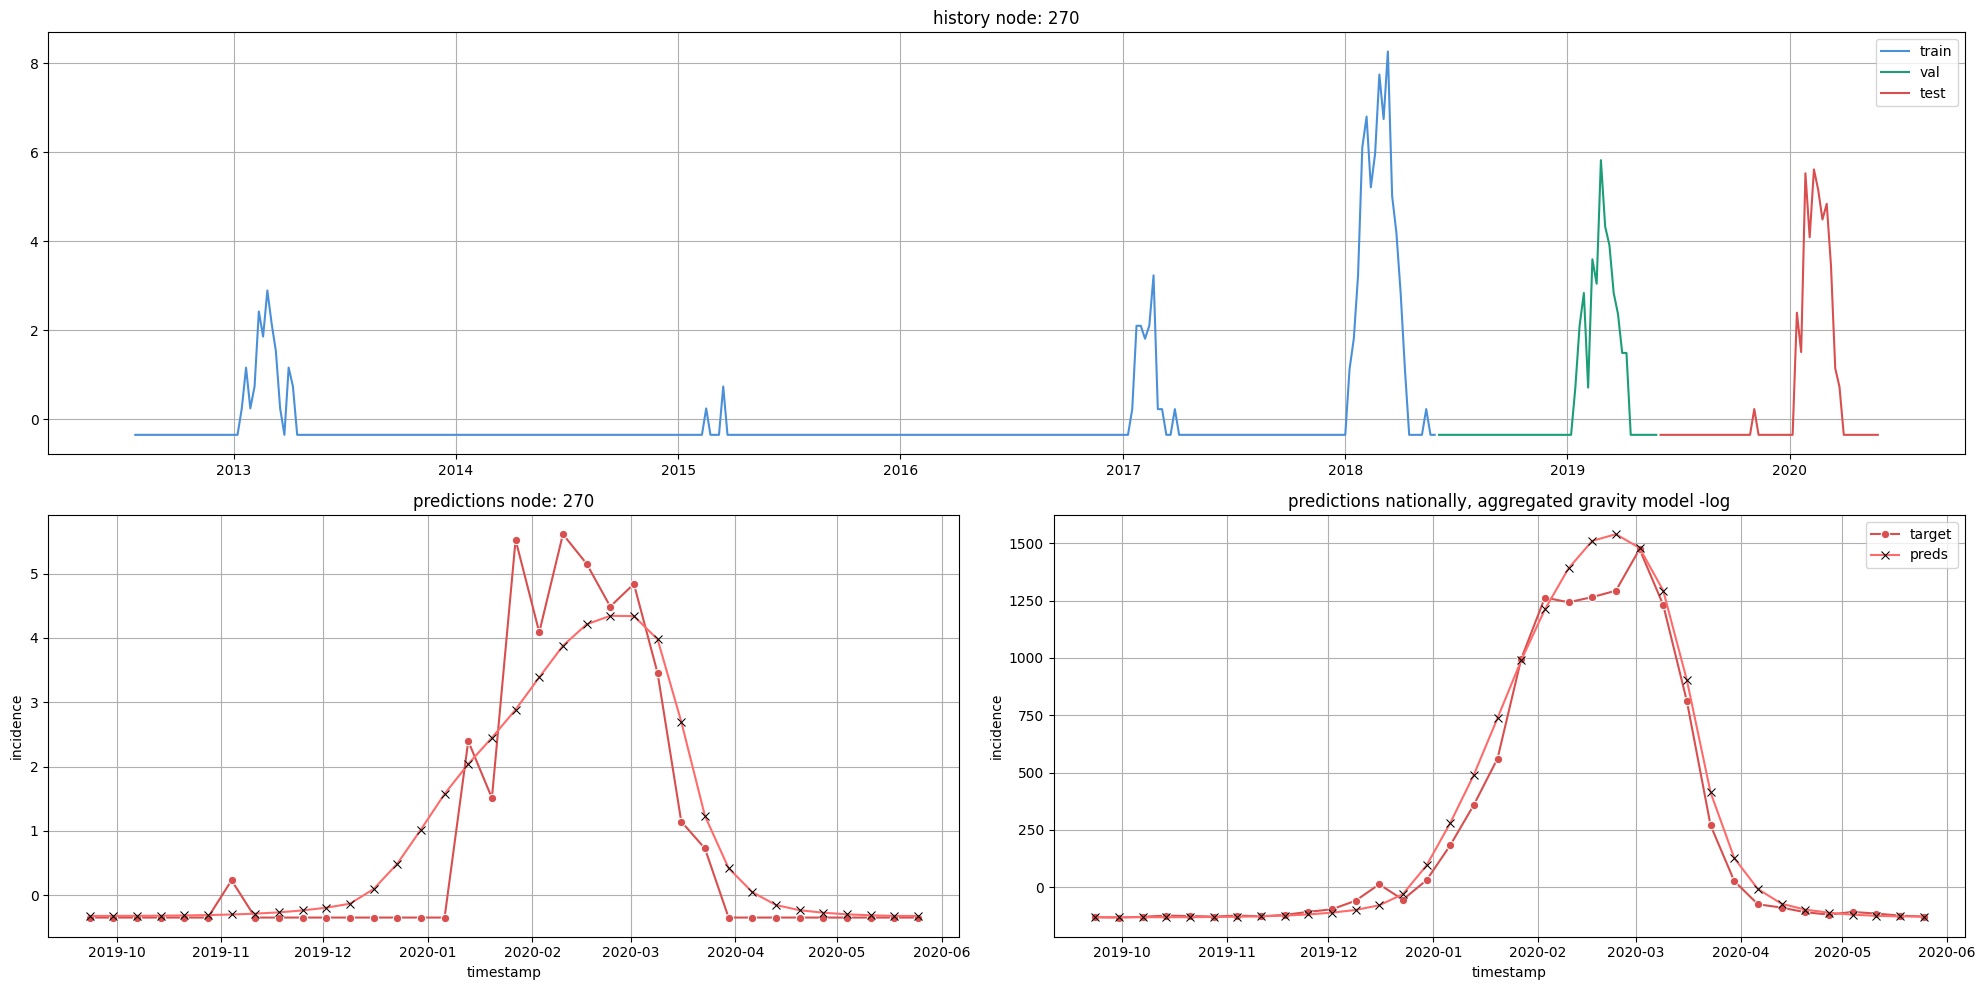

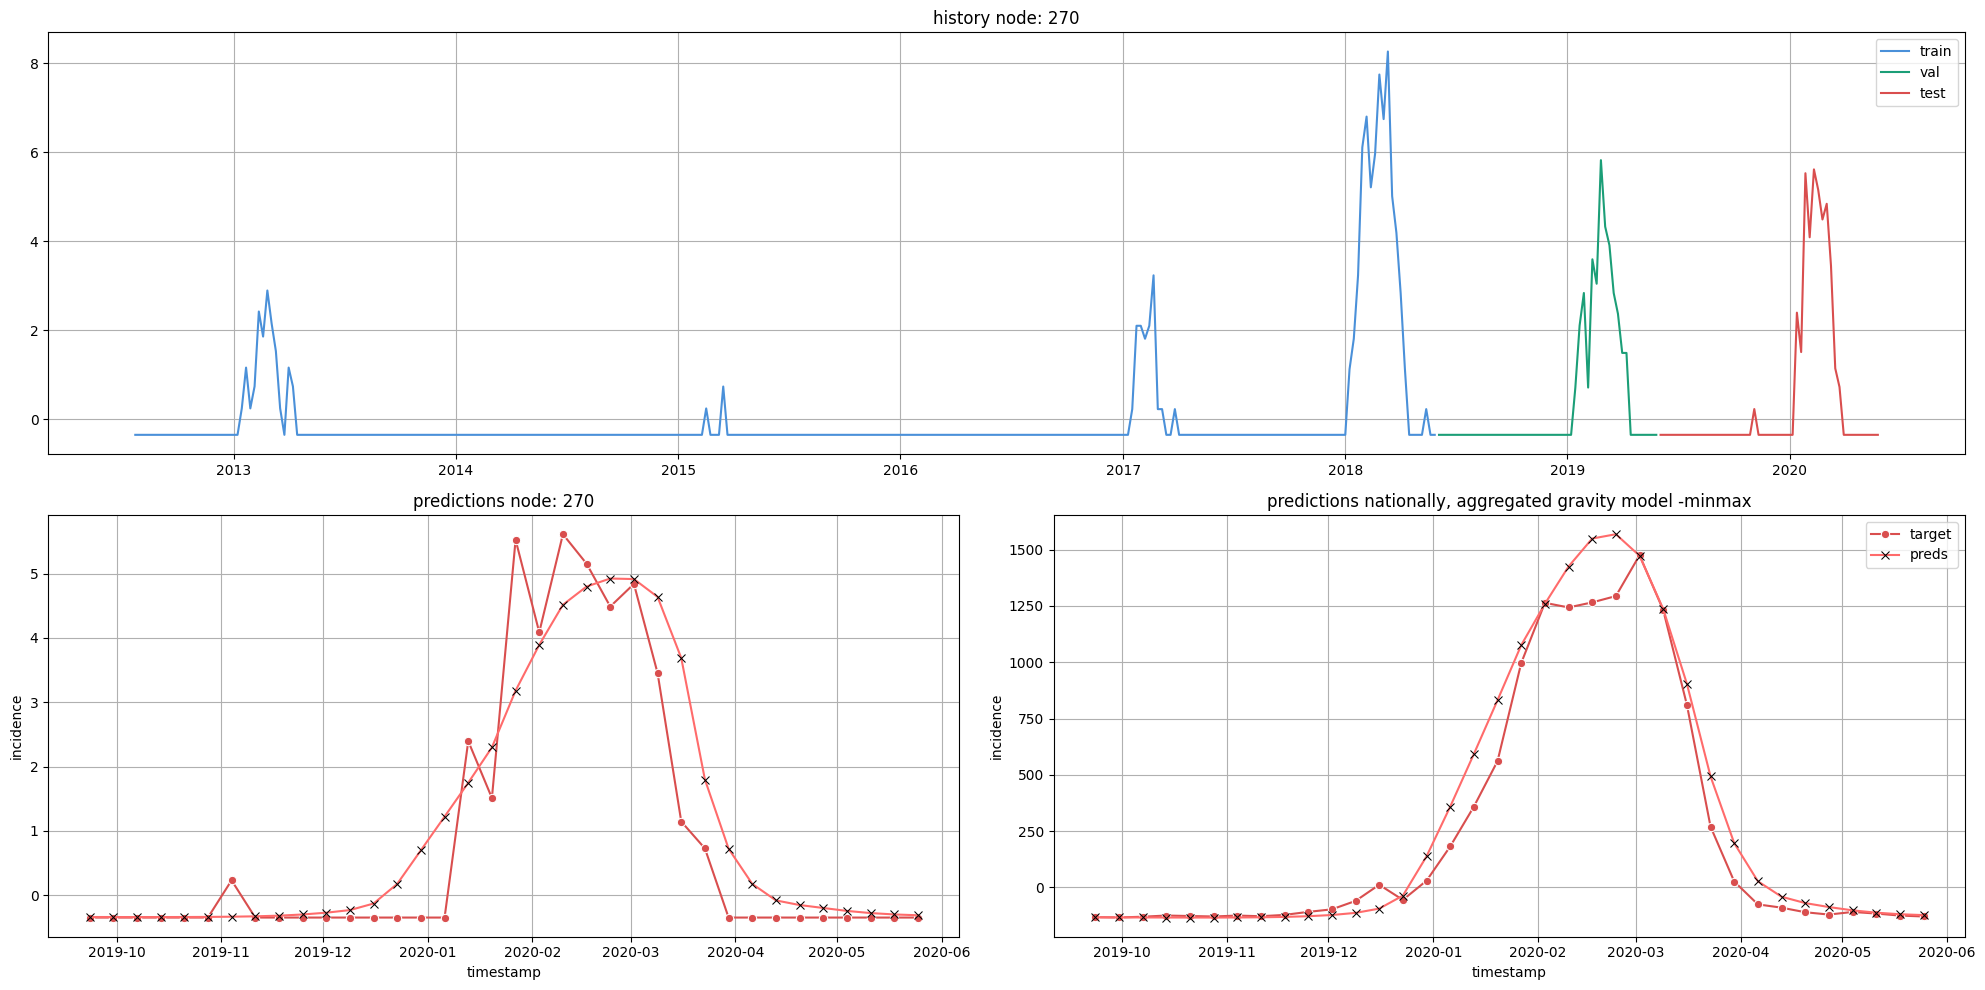

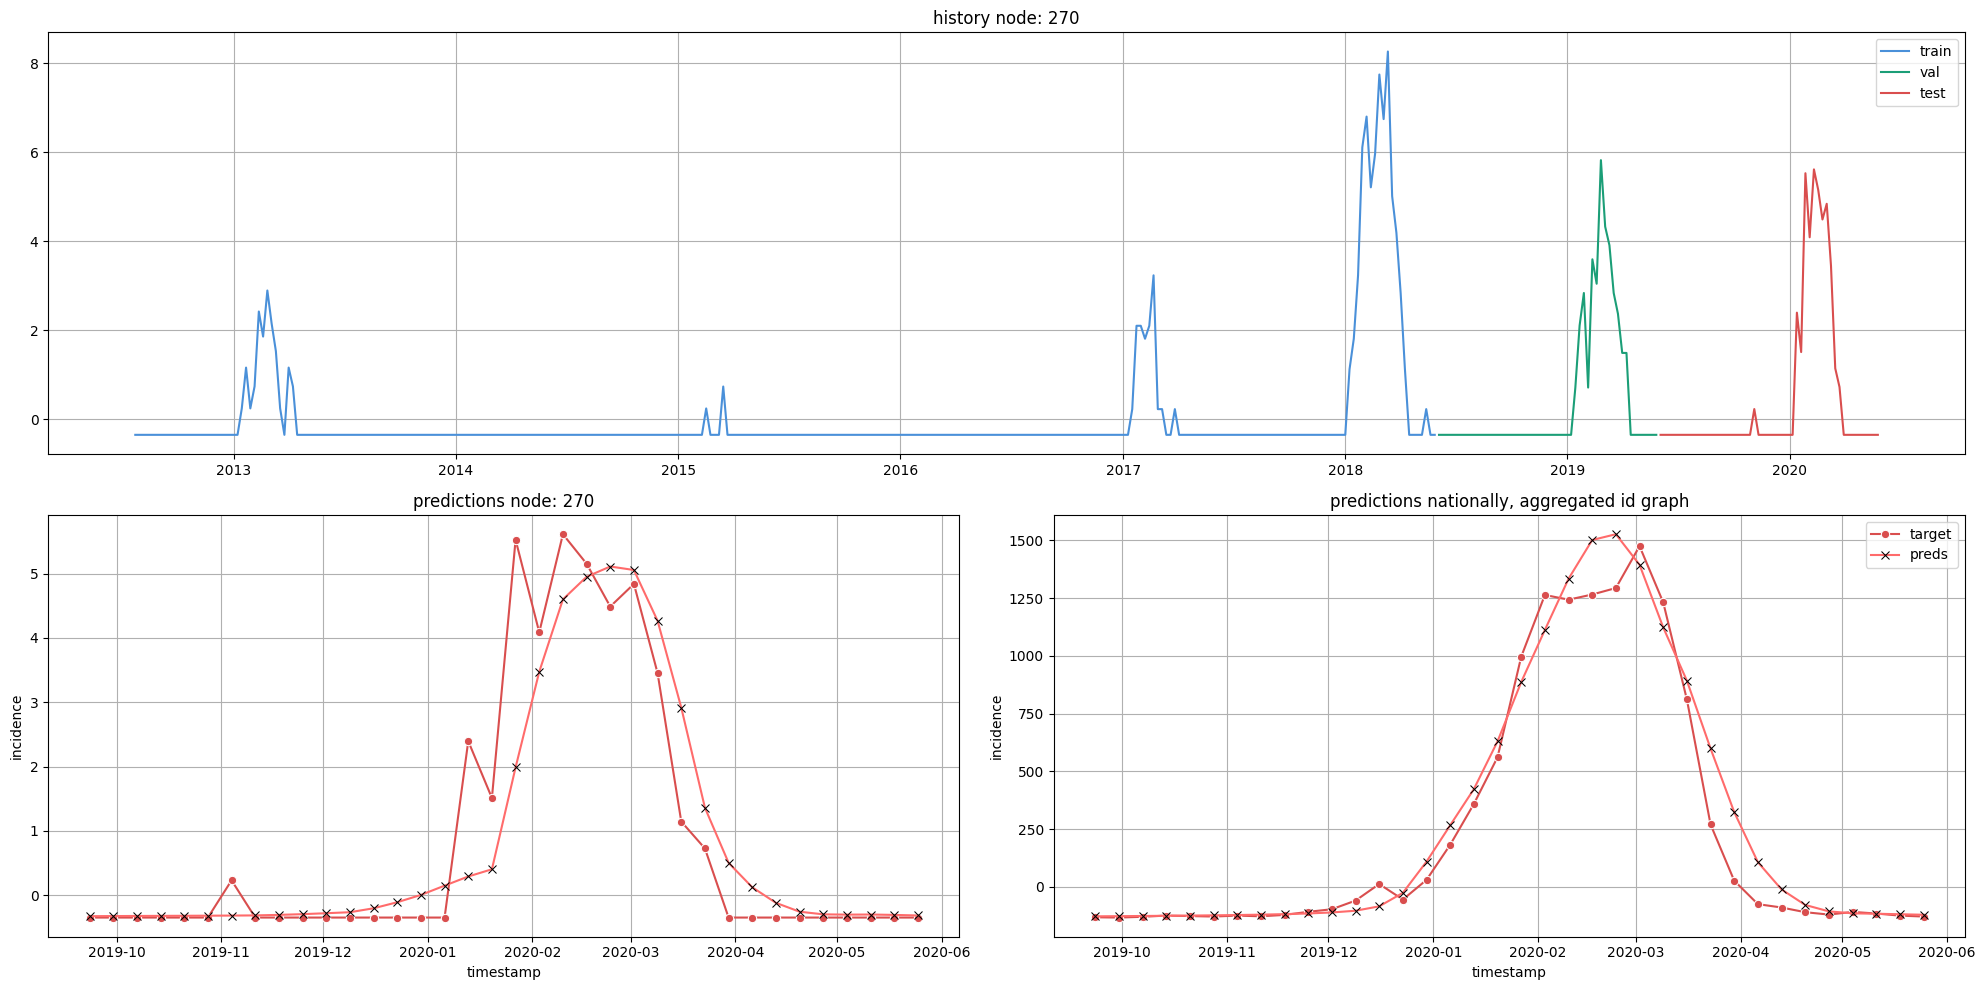

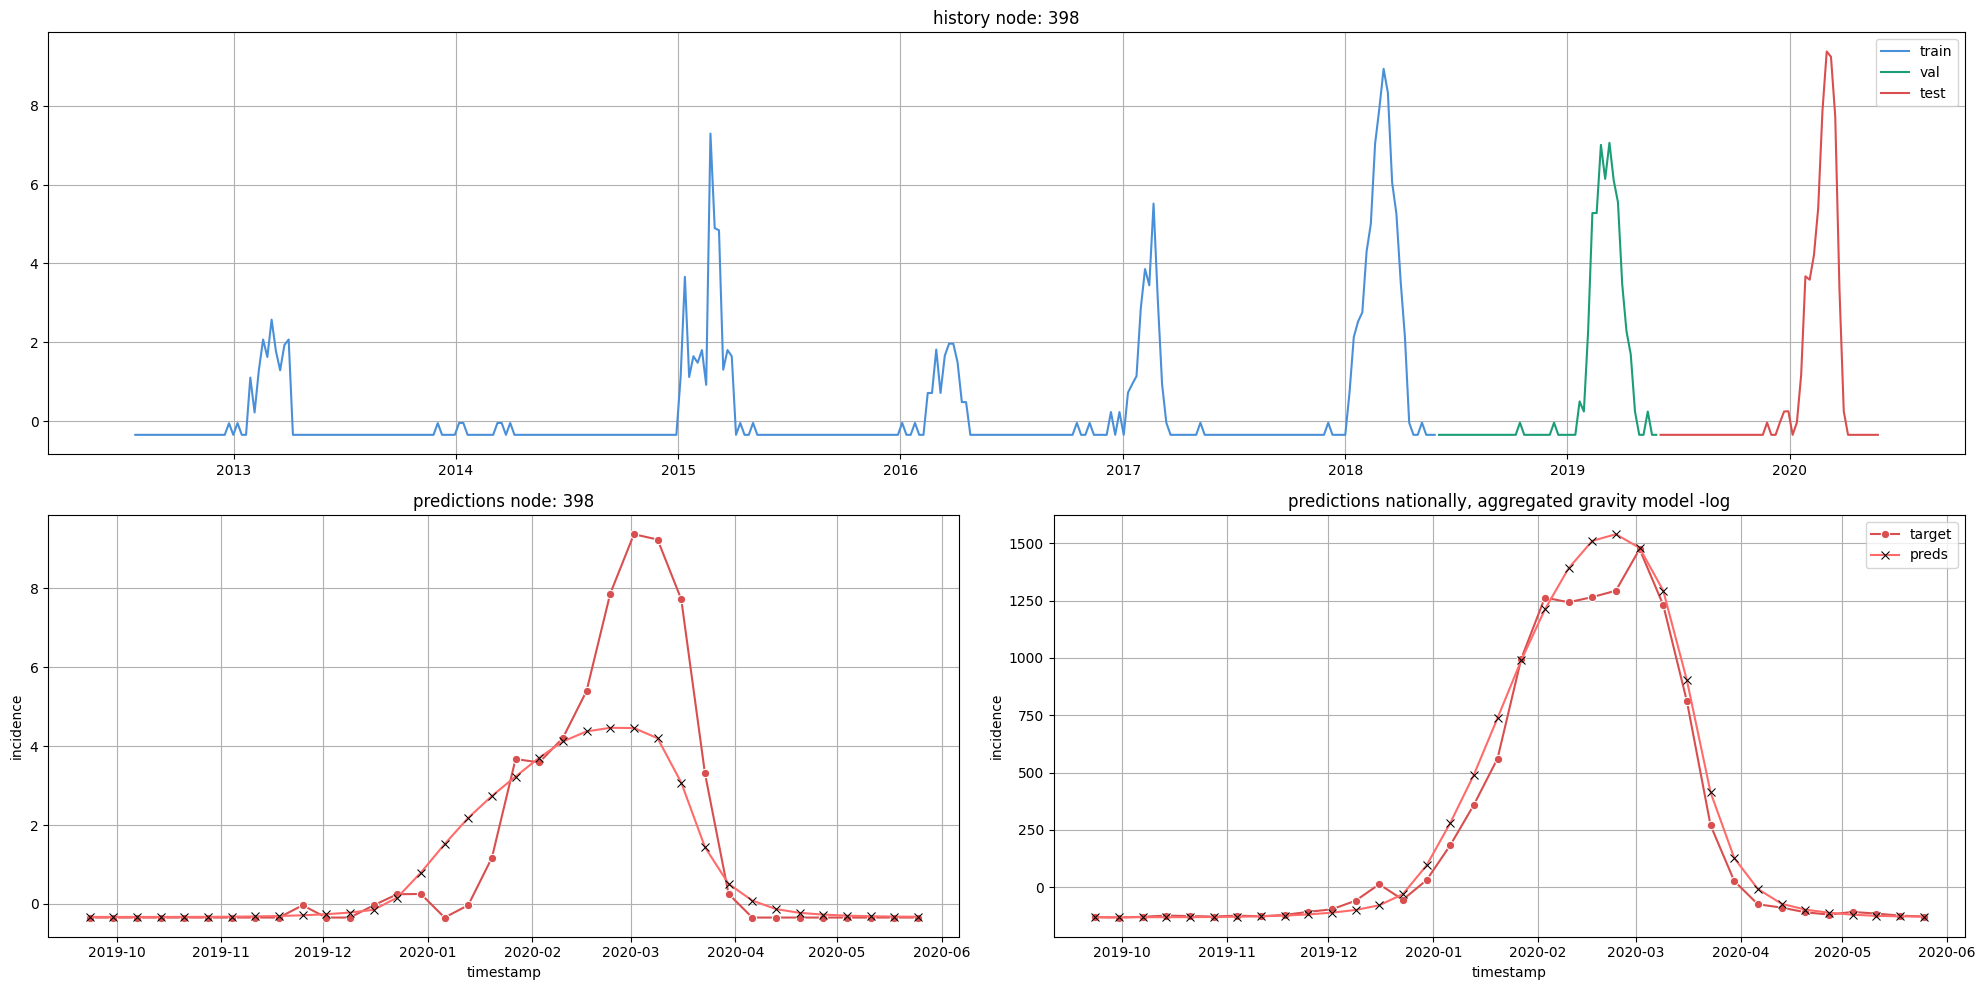

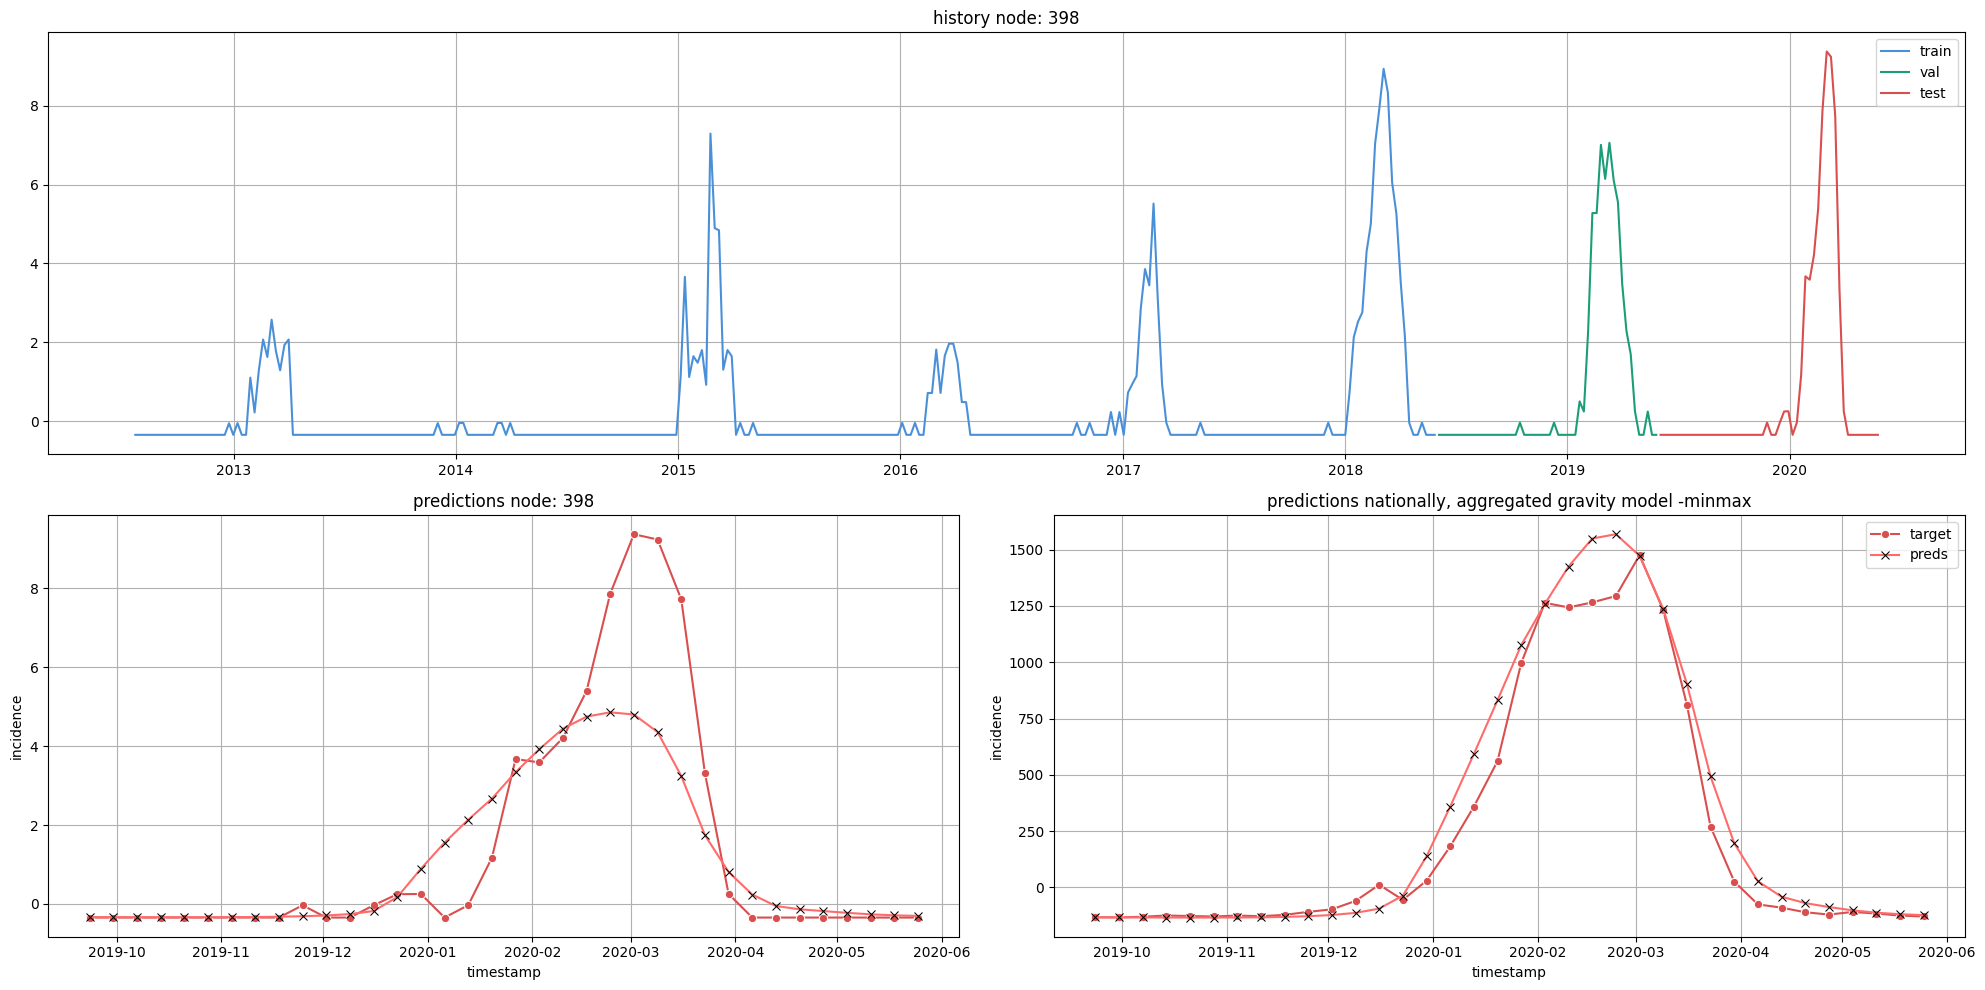

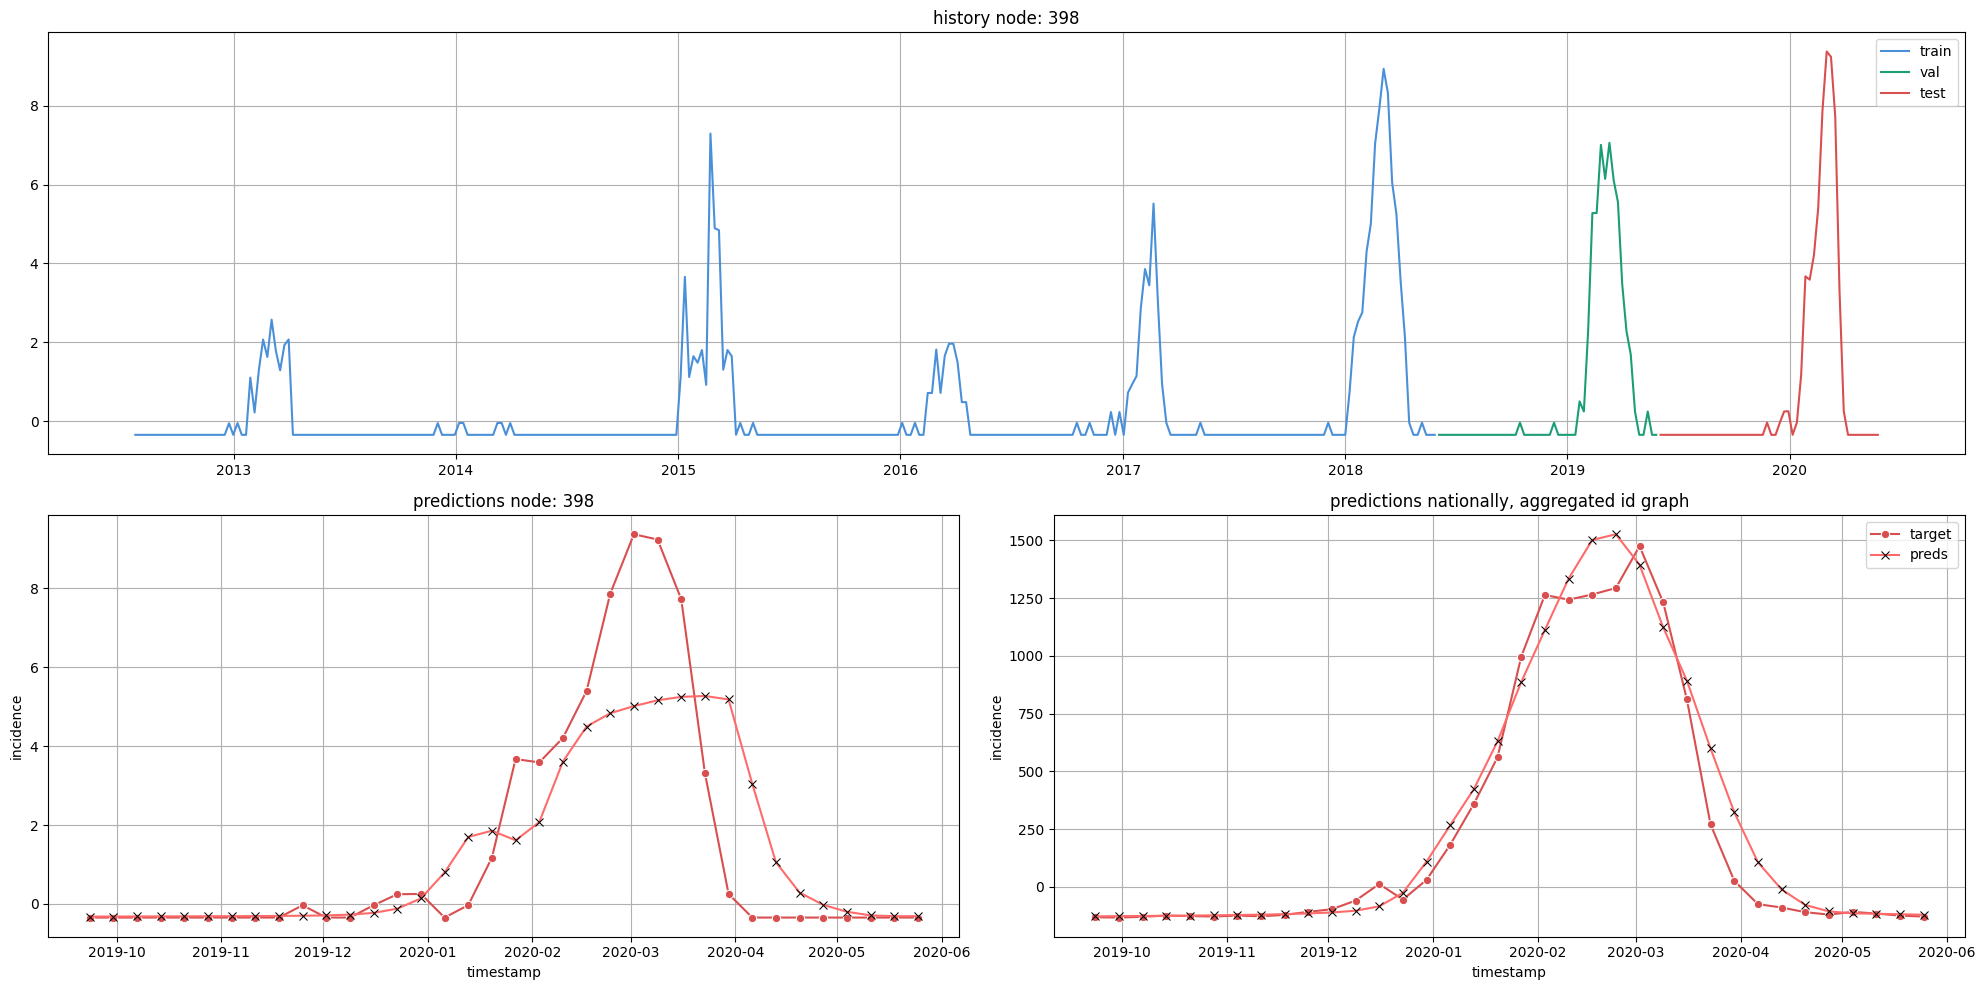

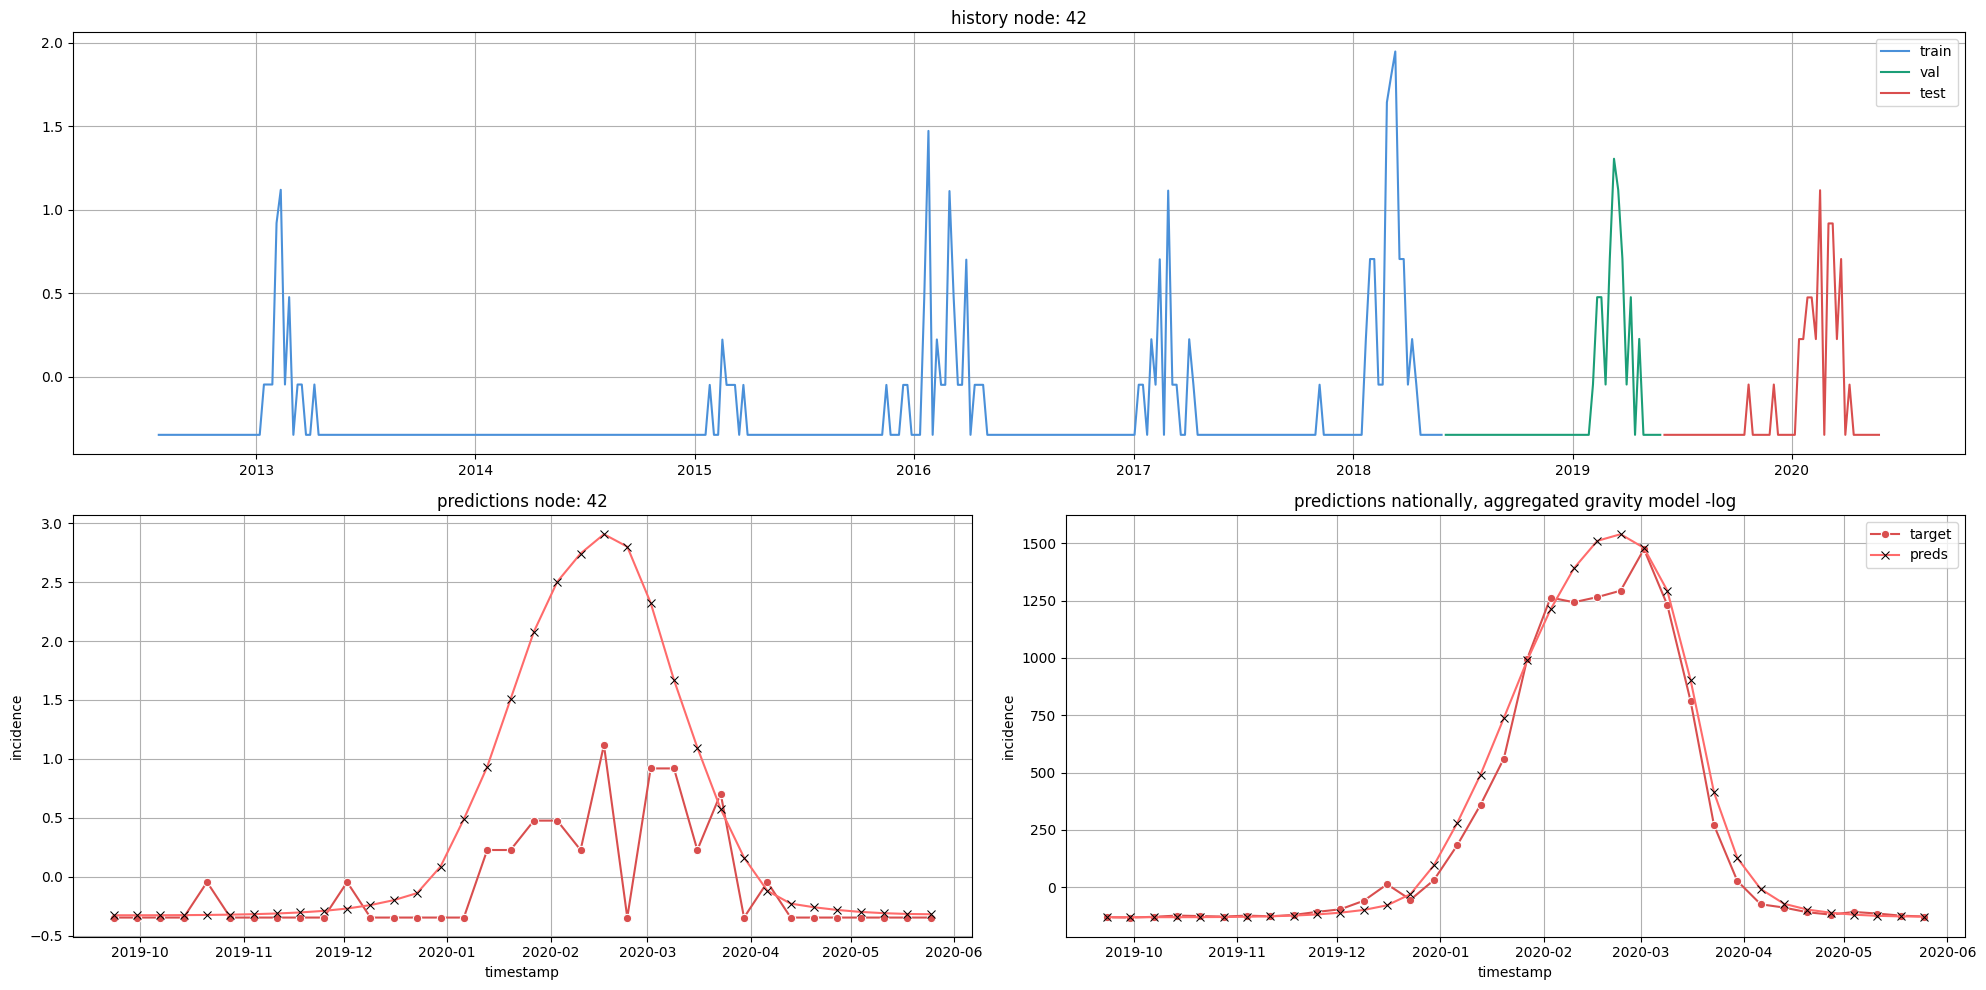

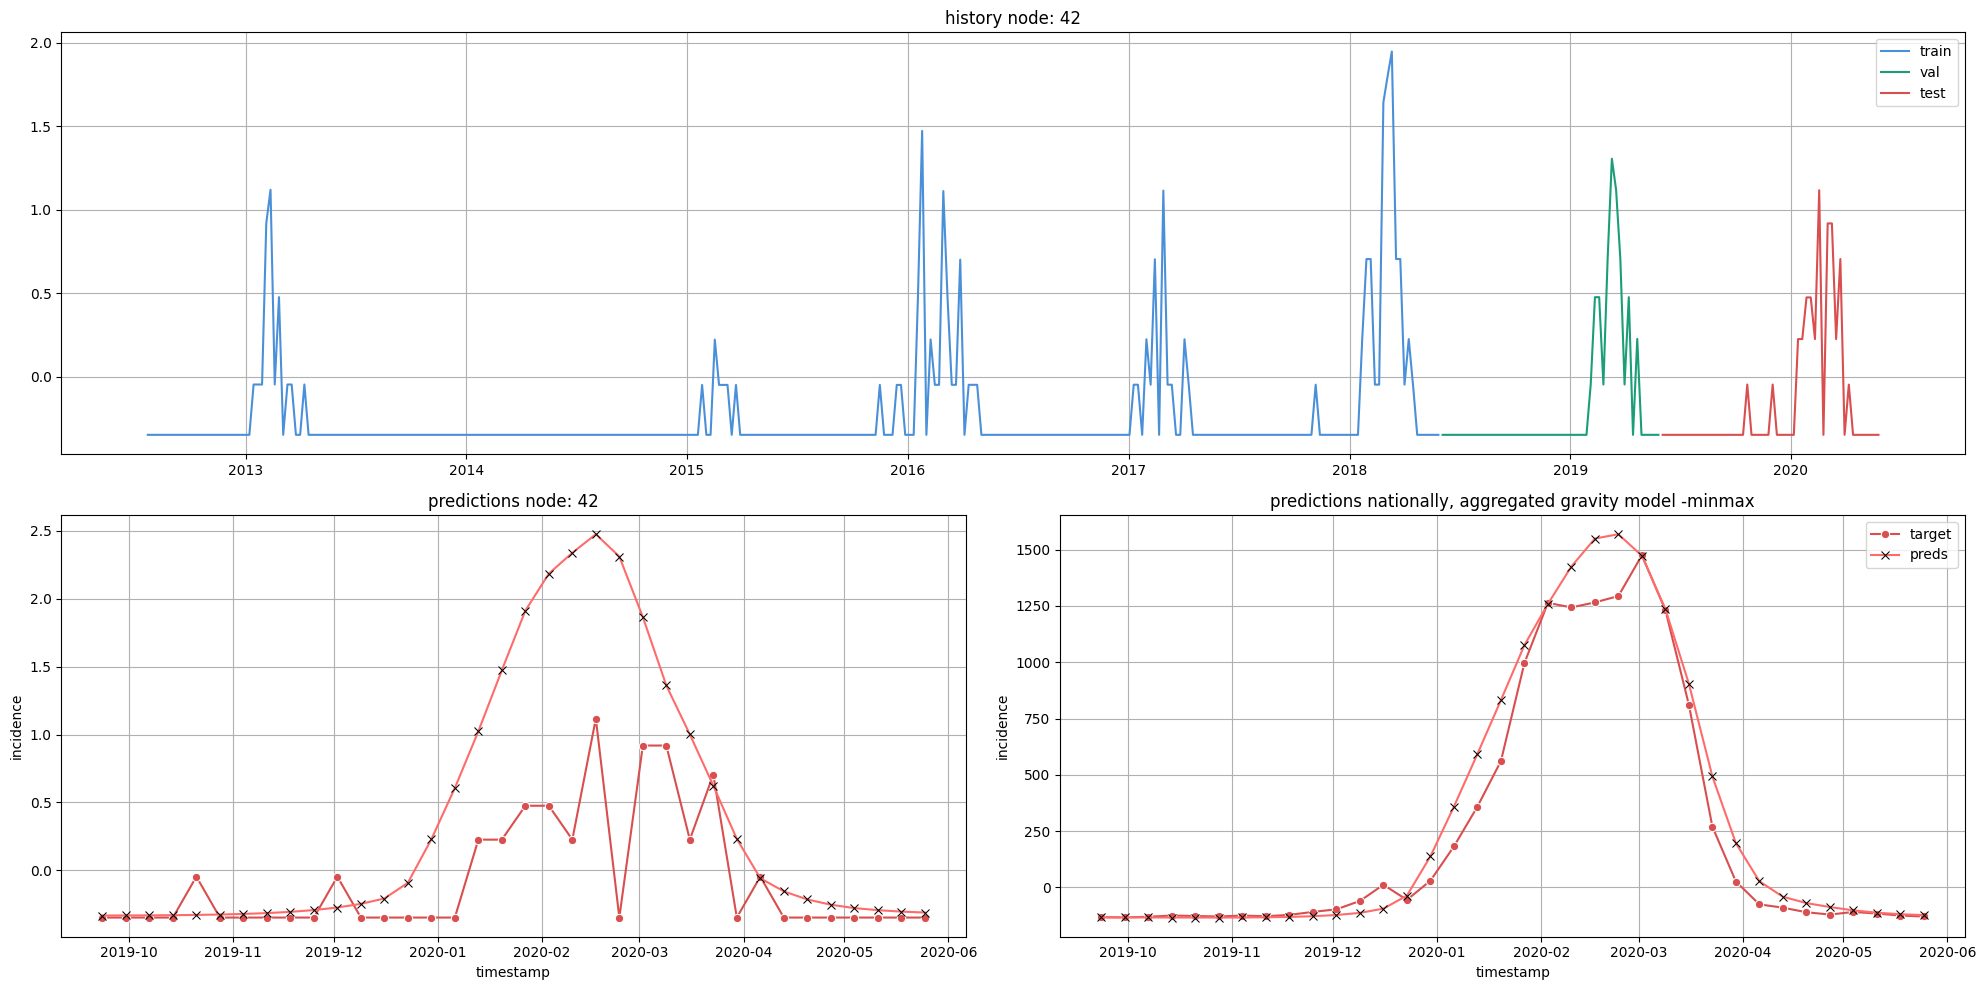

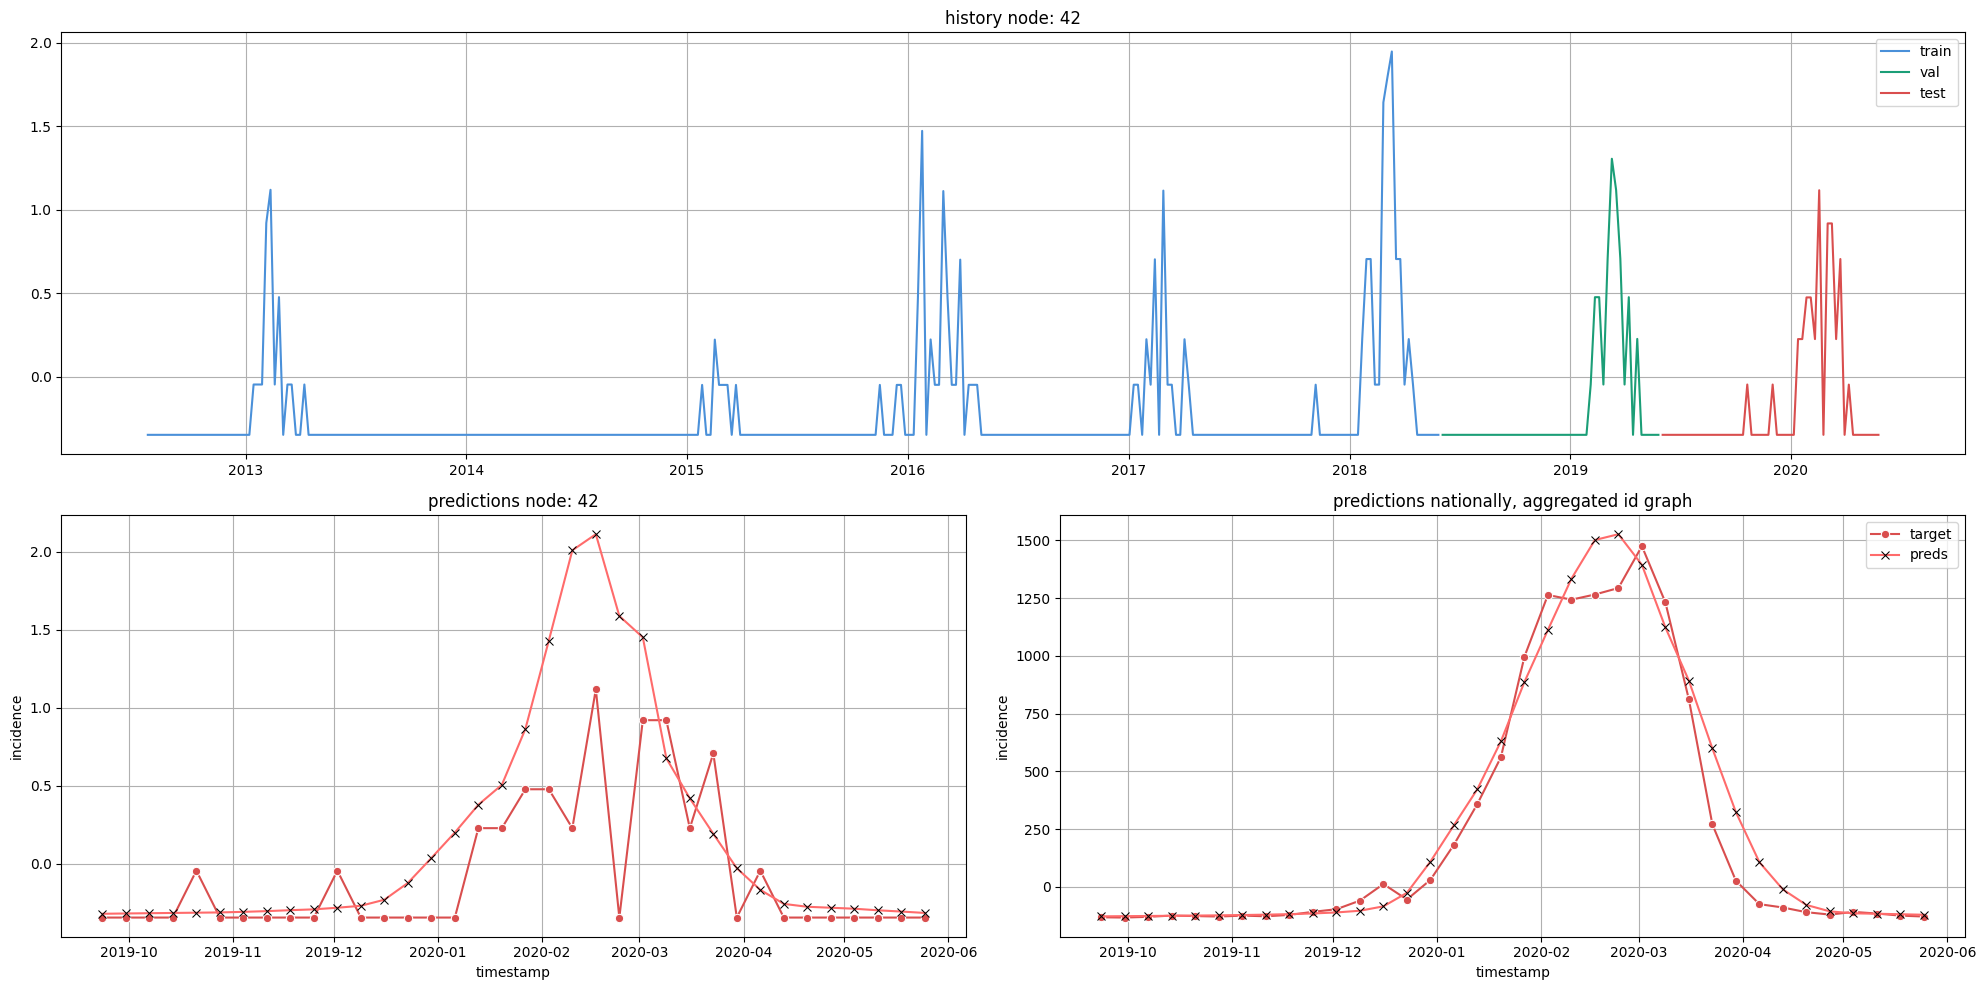

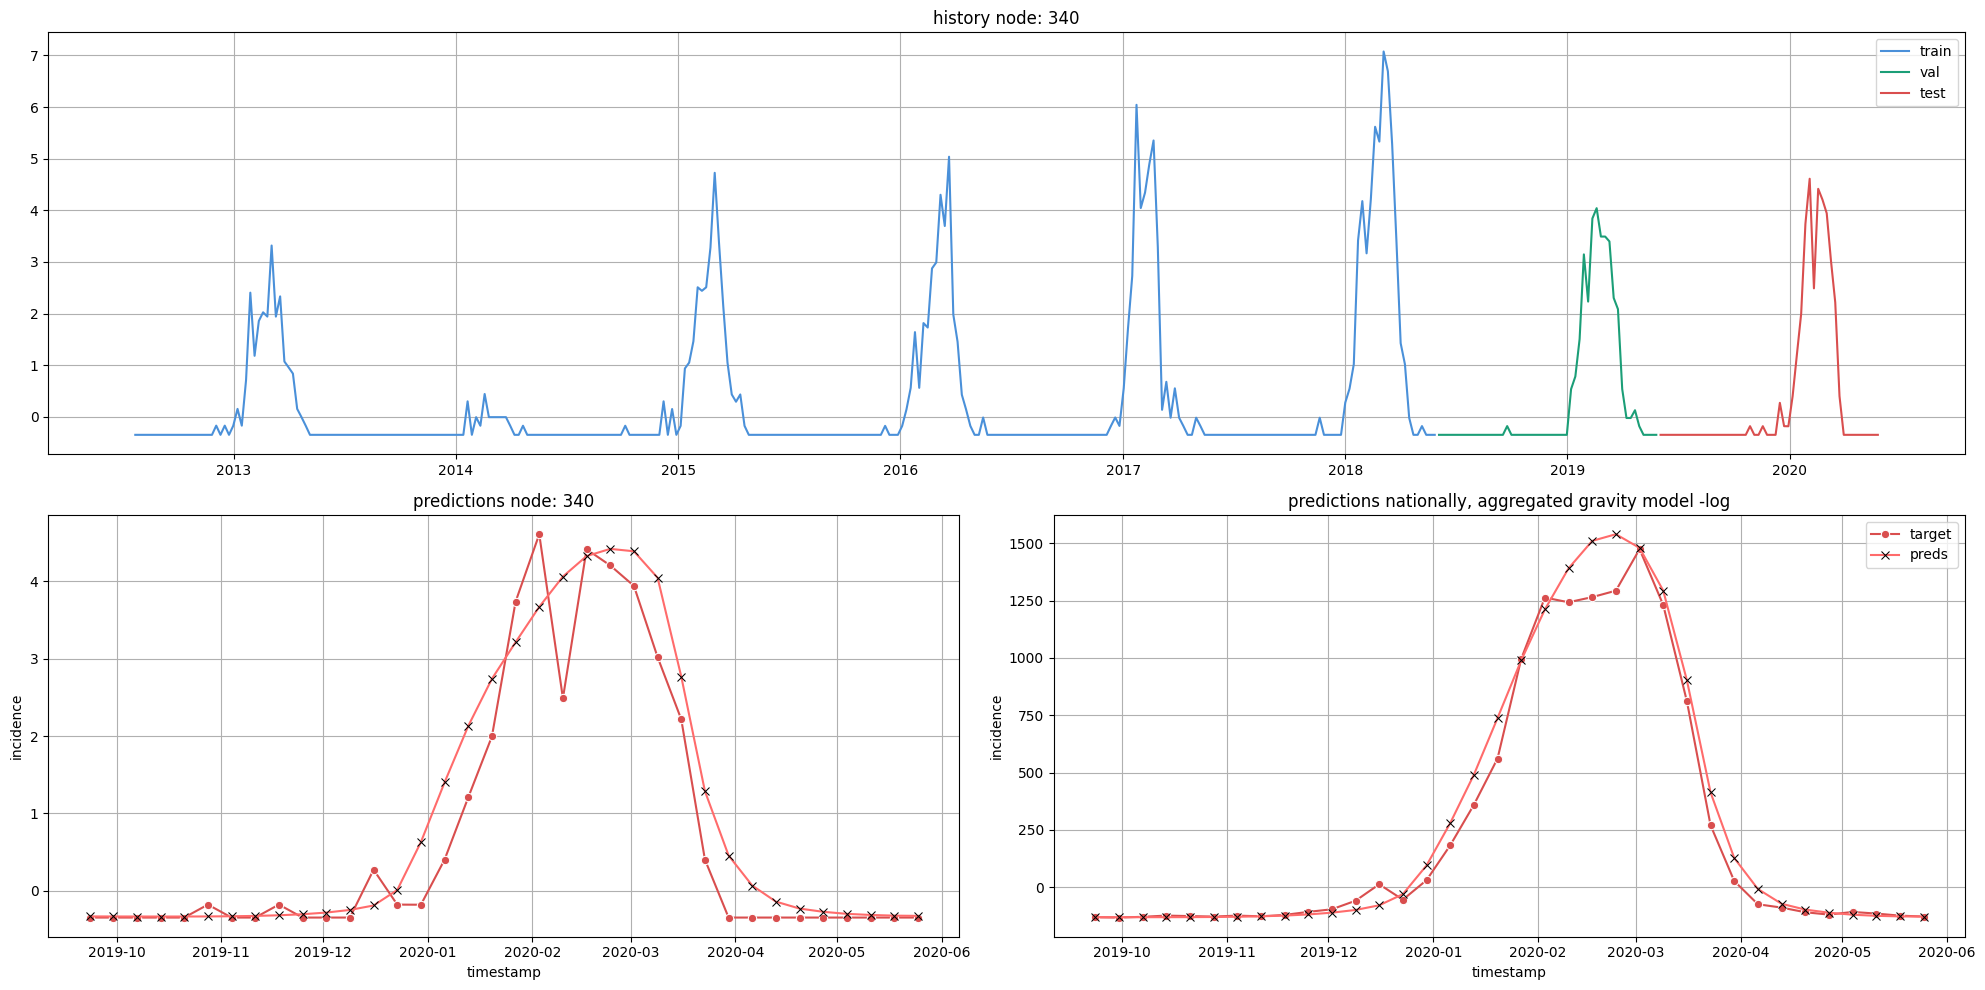

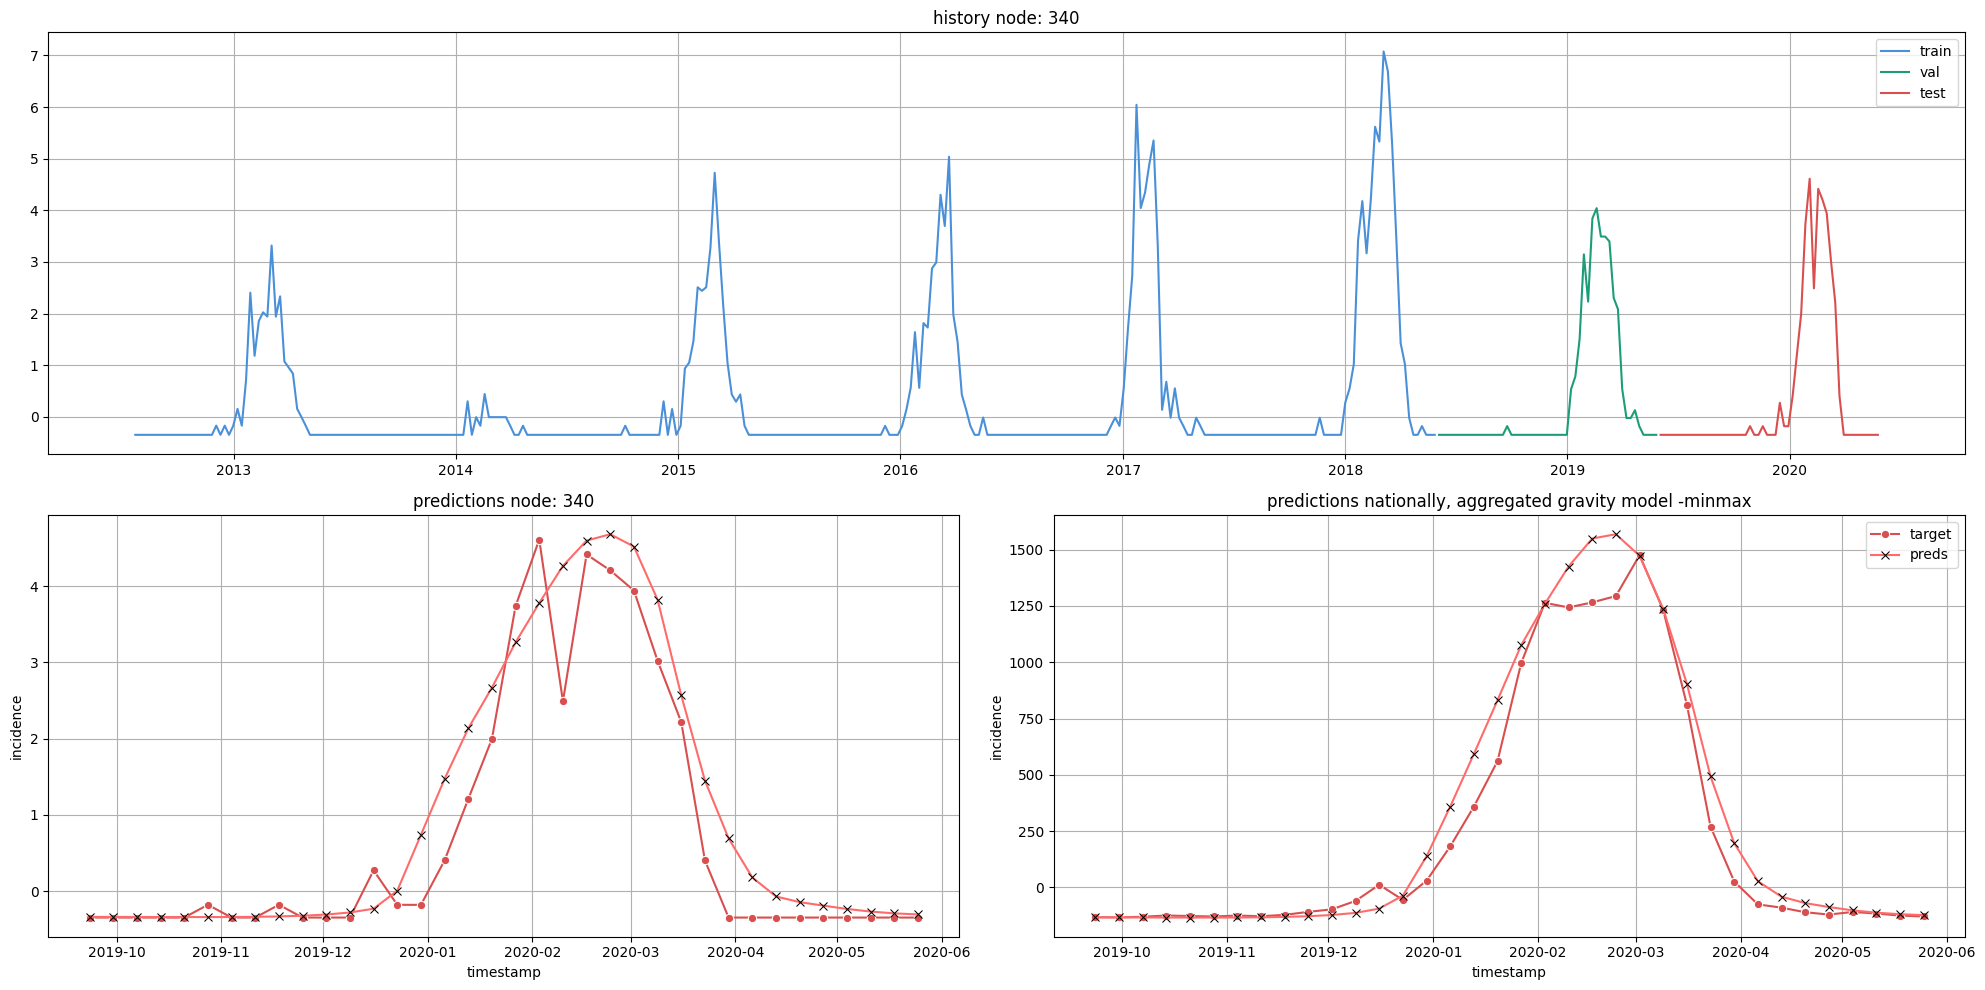

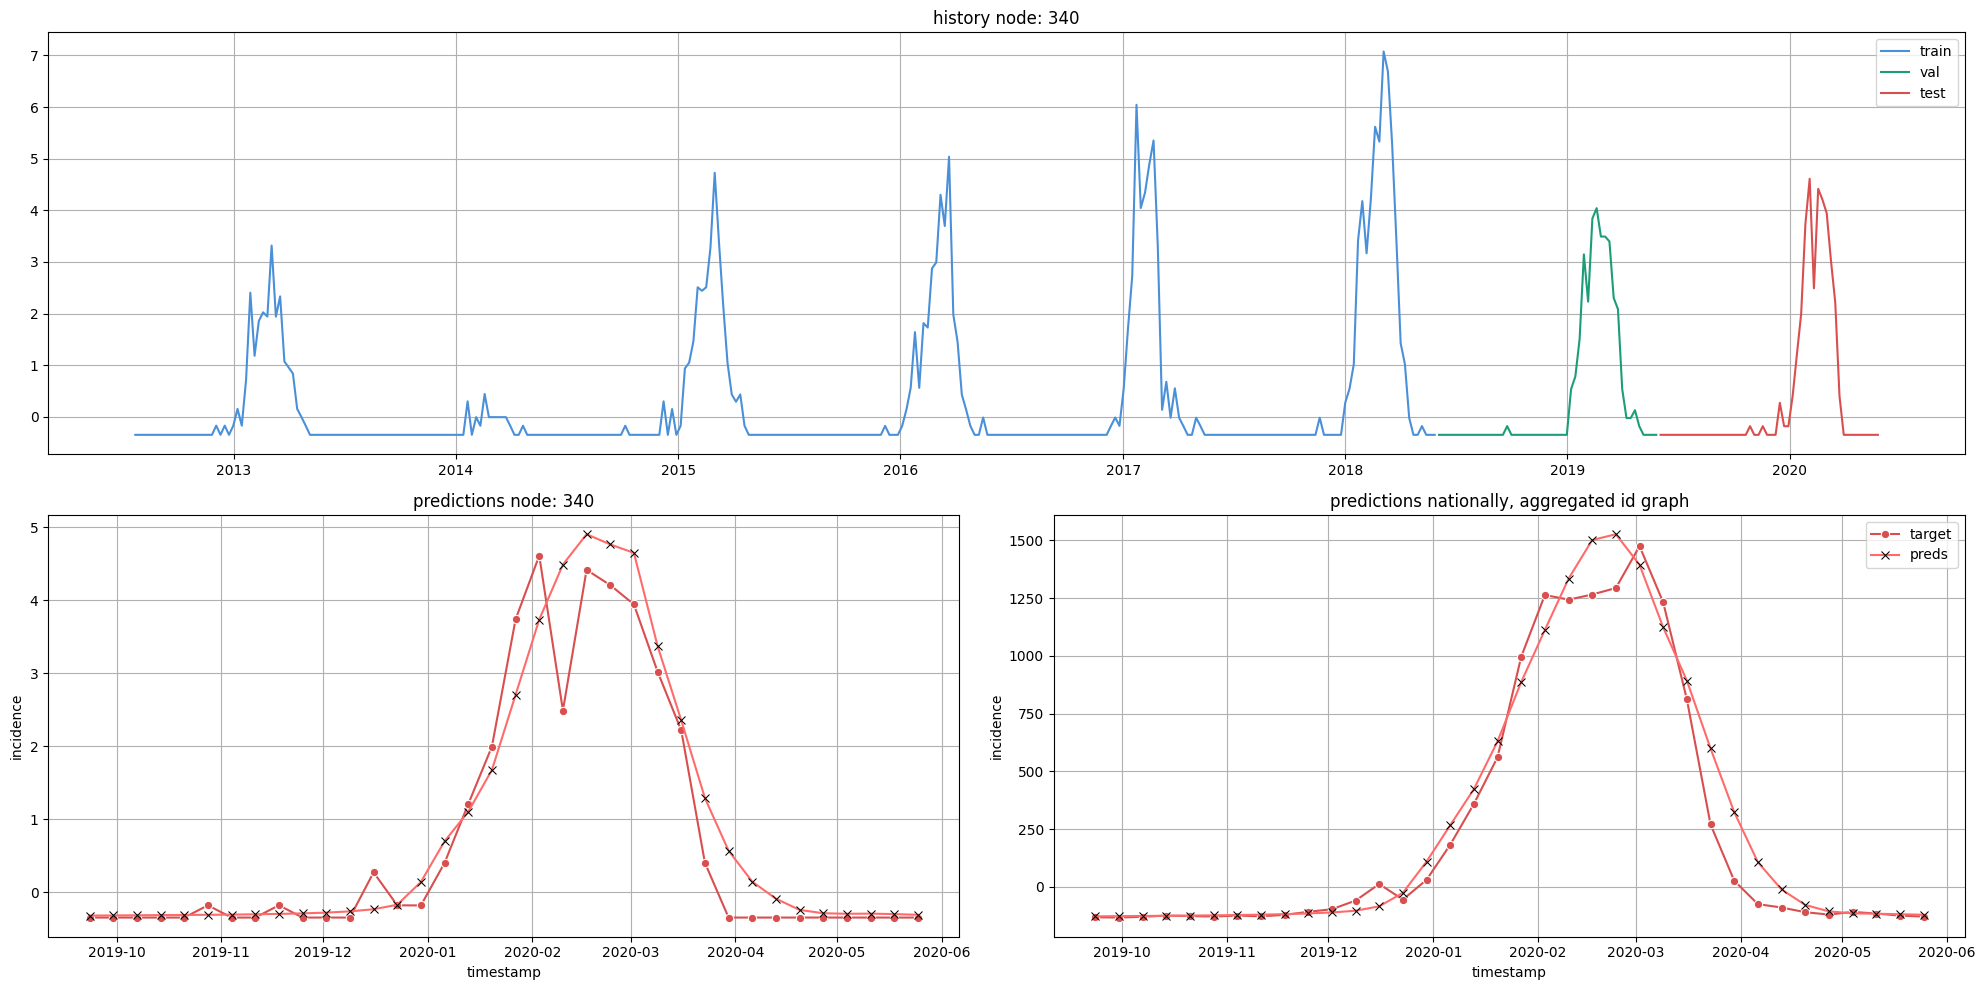

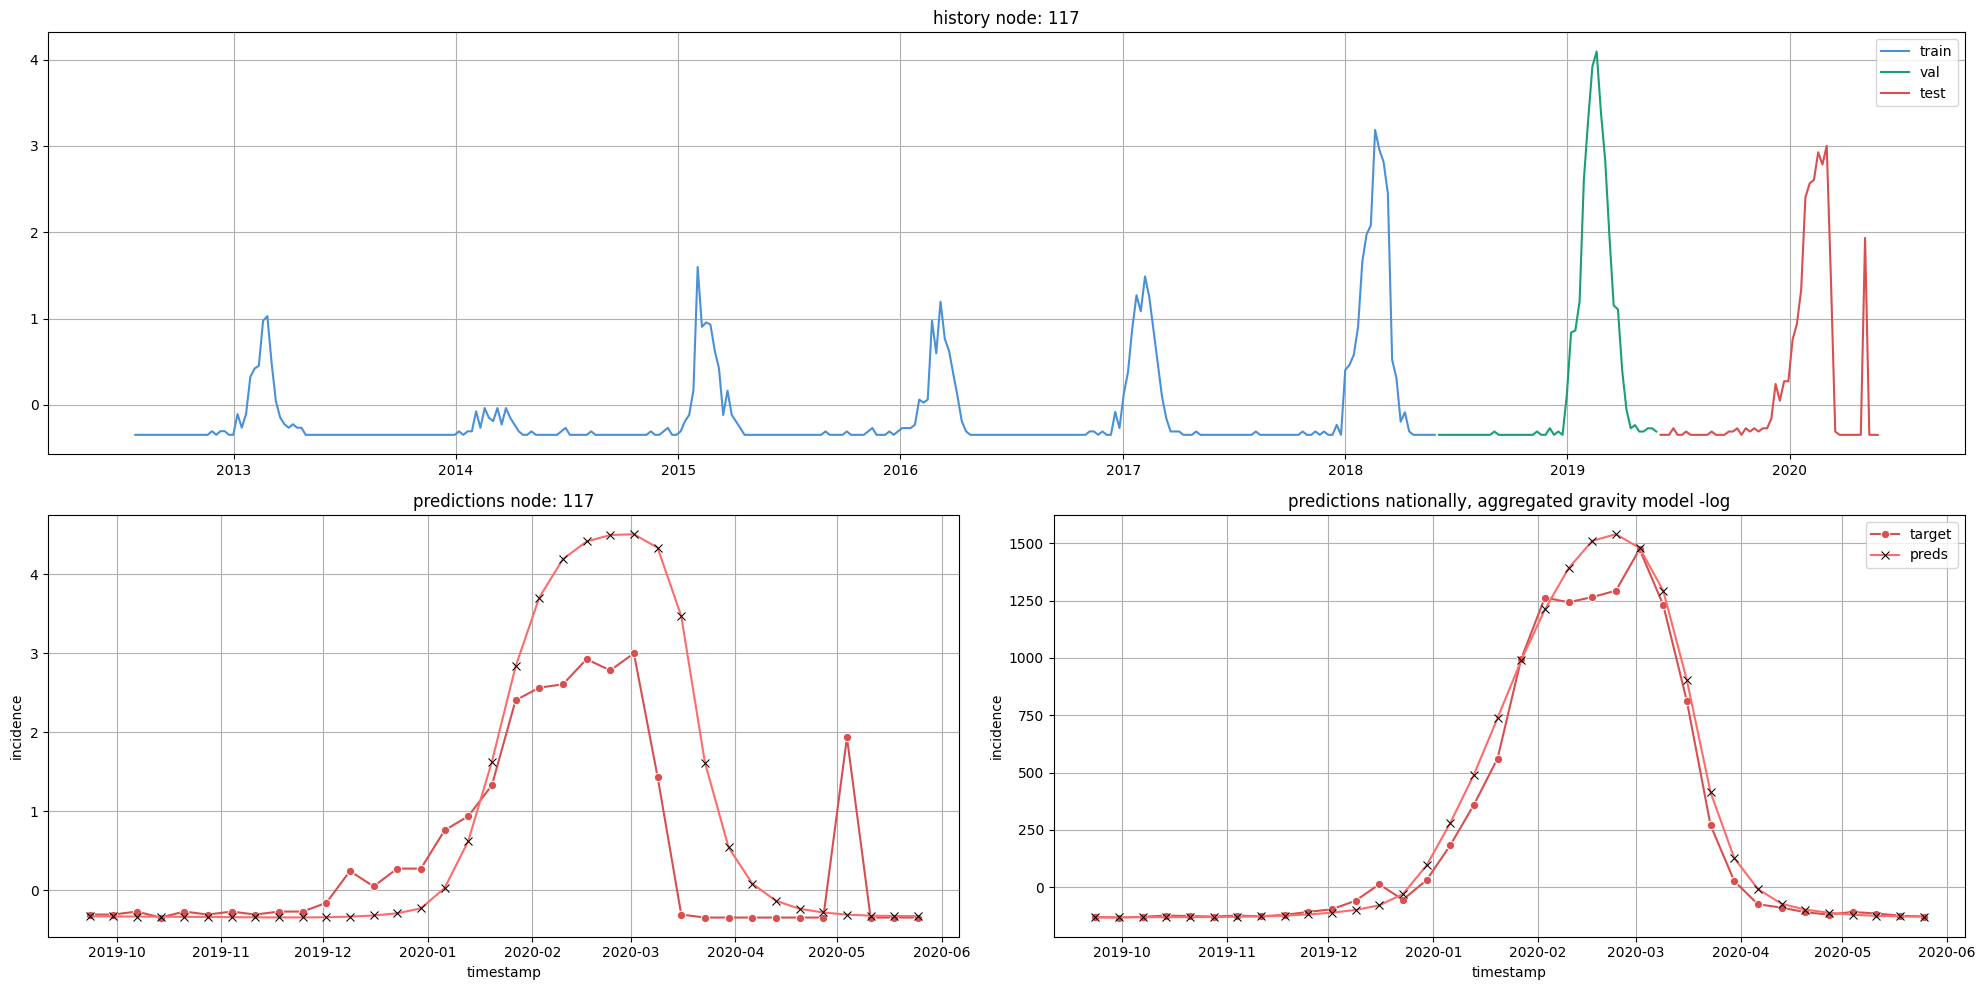

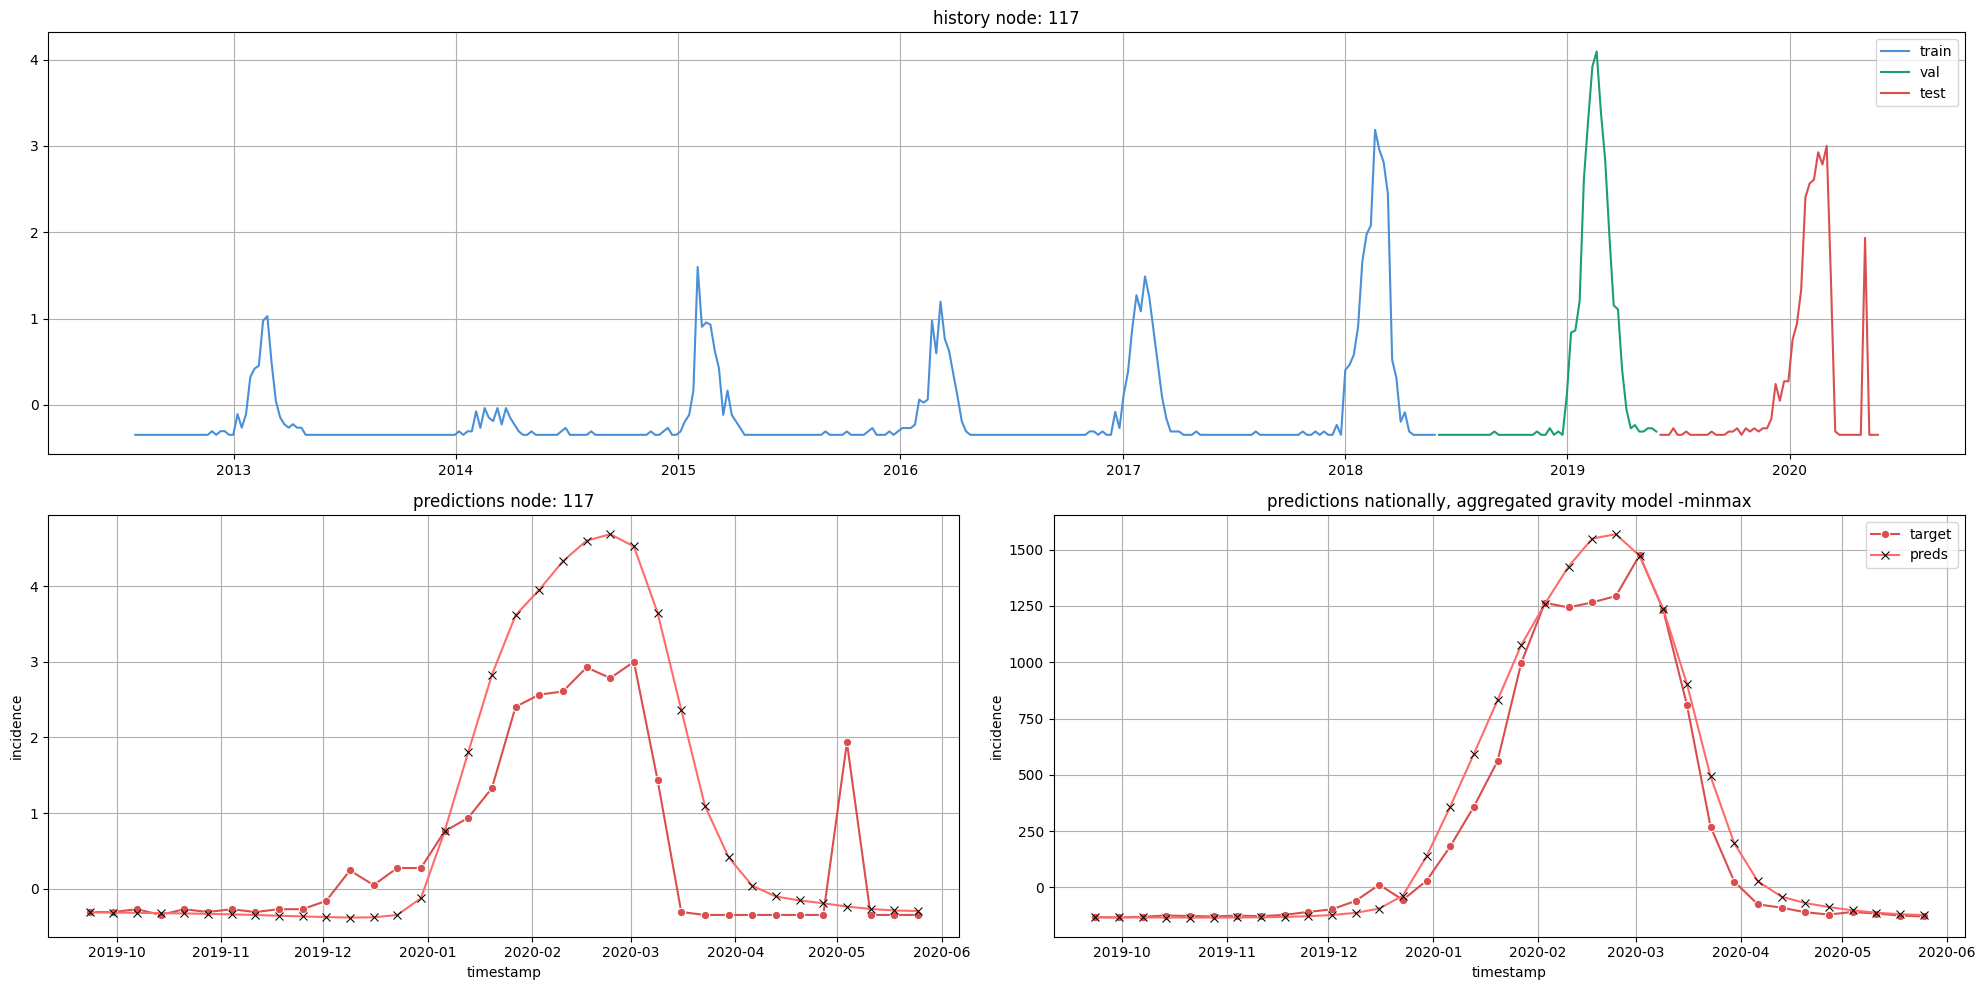

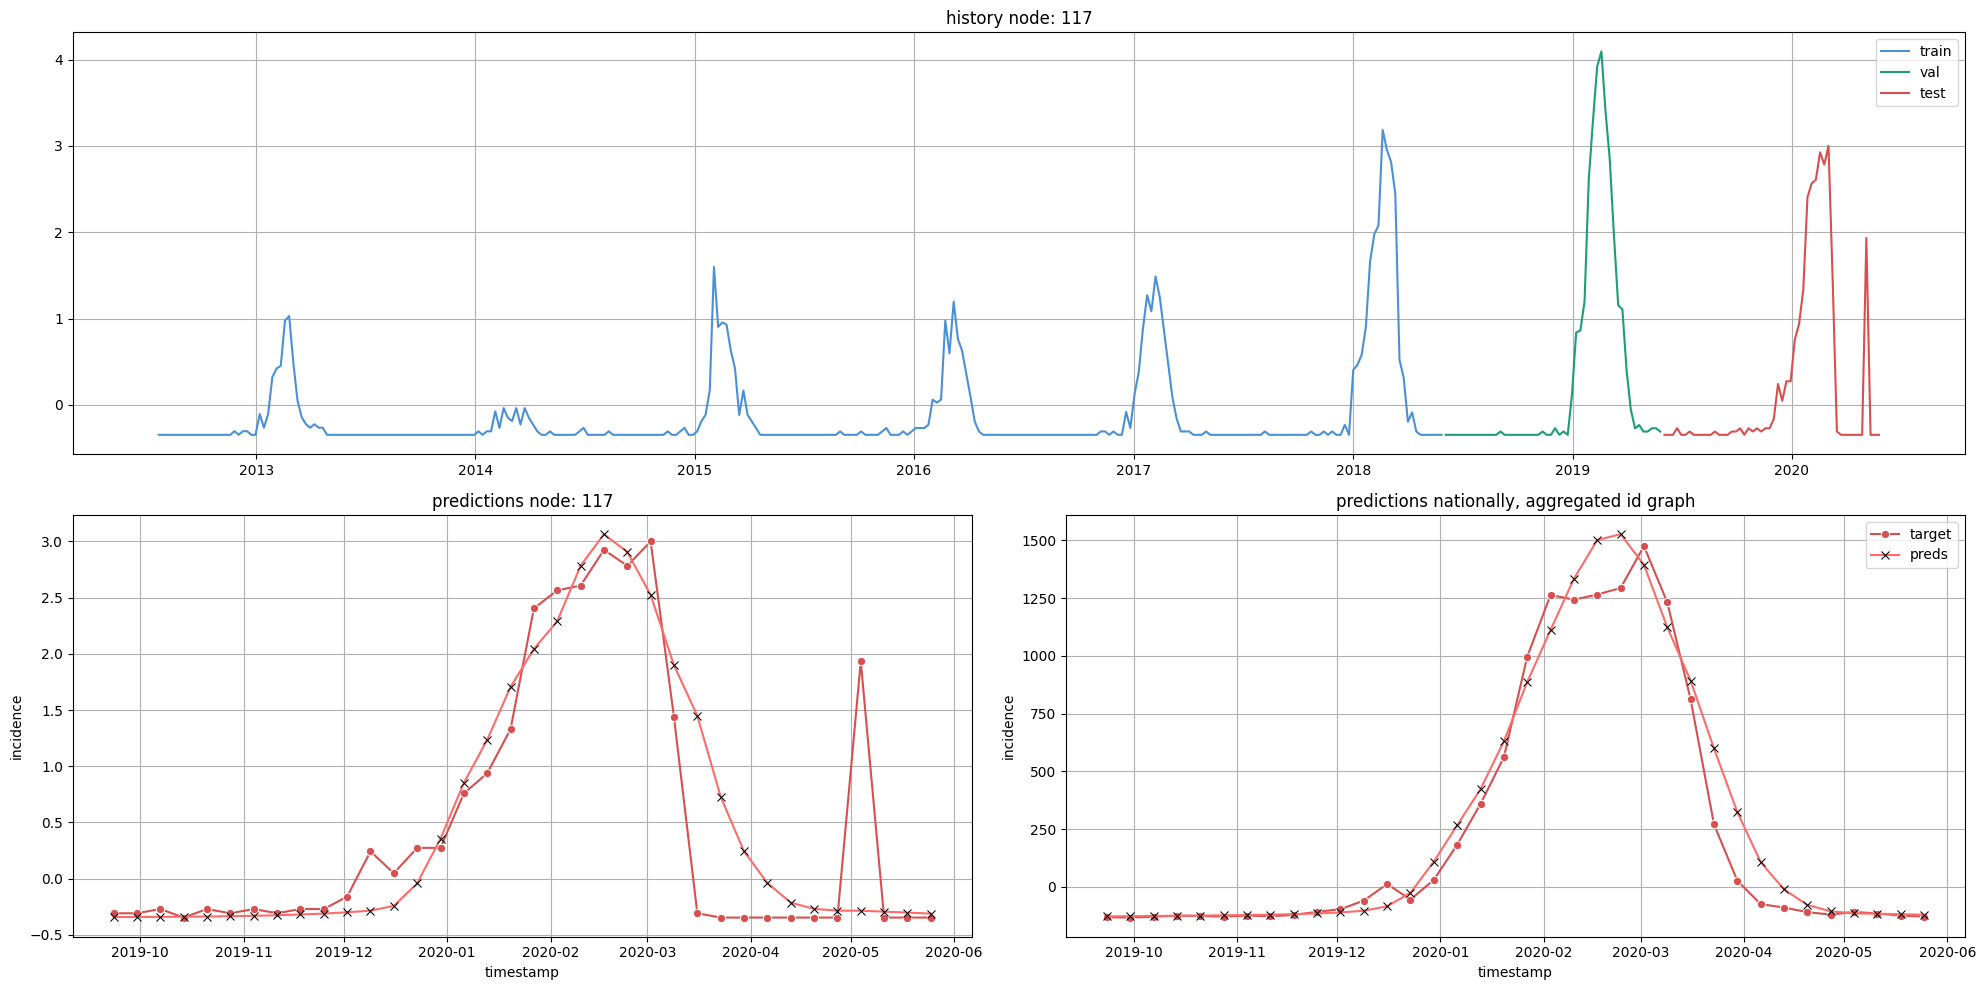

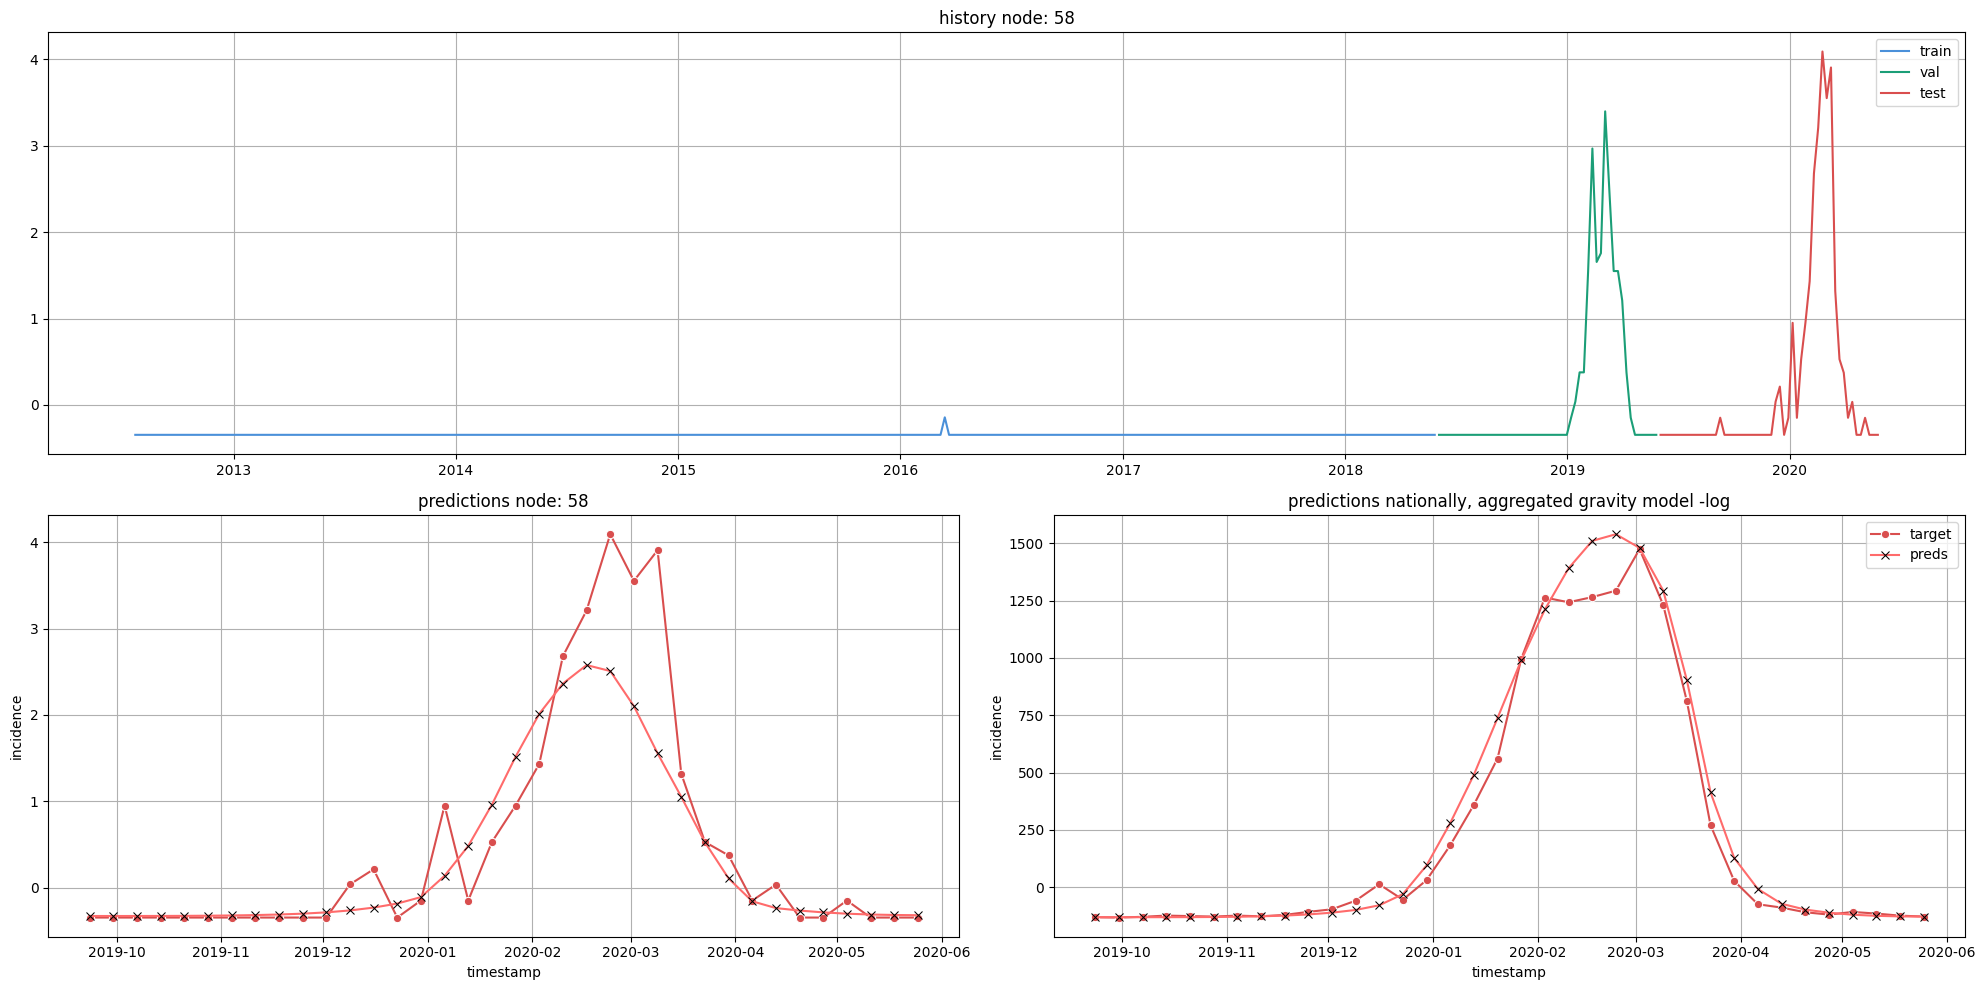

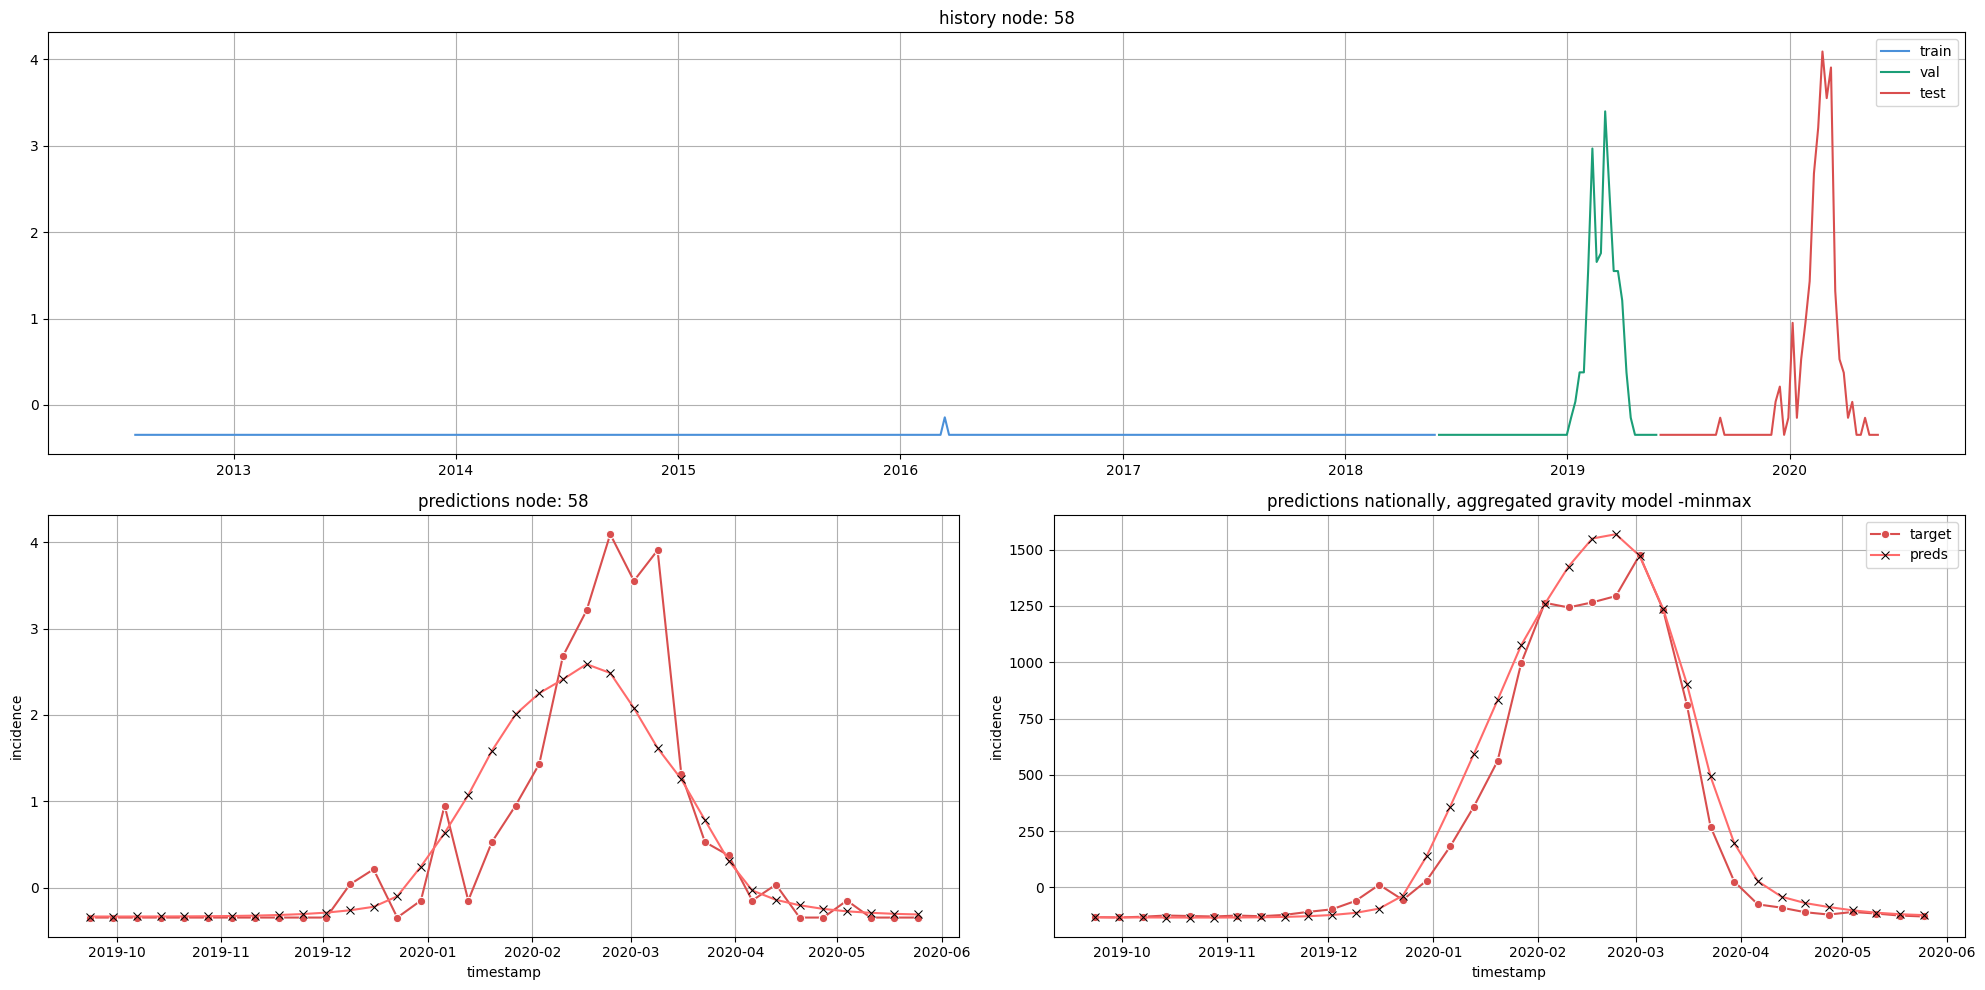

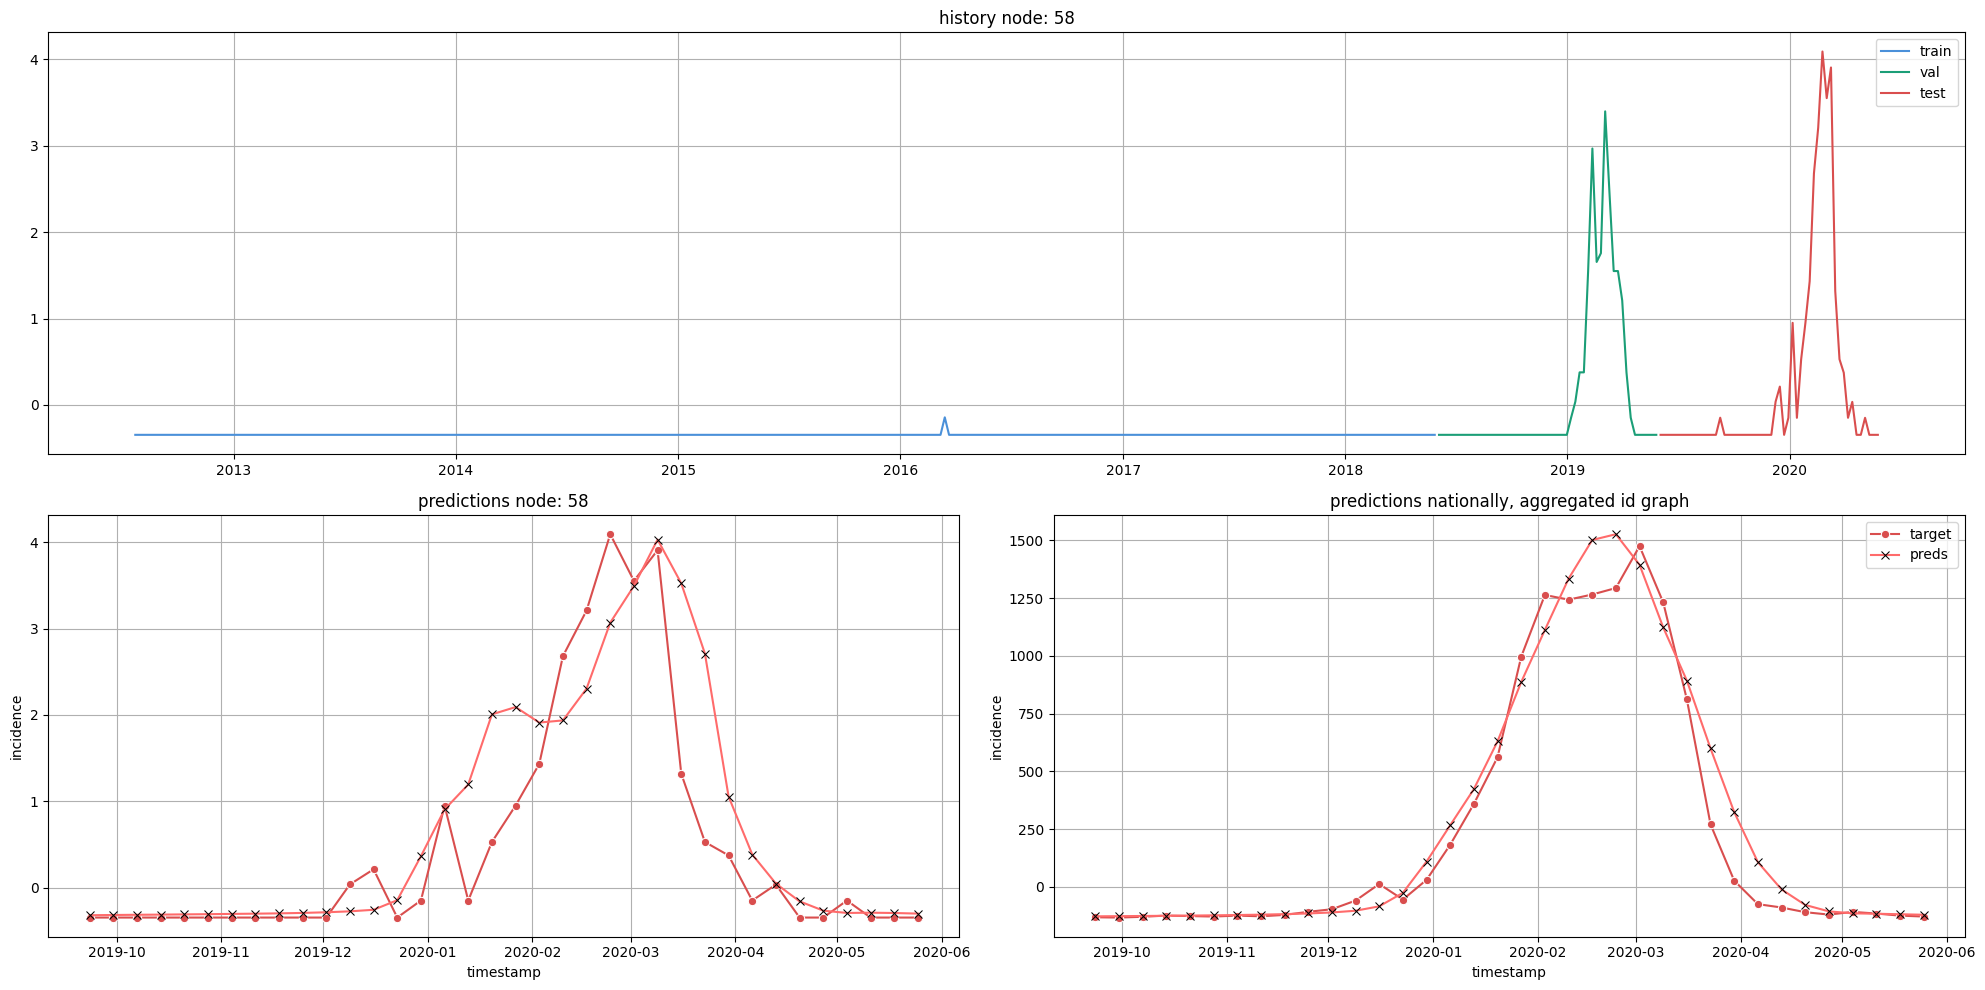

In [2]:
from src.models.temporal_gcn import TemporalGCNModel
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor
from src.dataloading.epidataloader import EpiDataLoader

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(1,8))
epidata.preview()


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_log').construct_dataloaders(periods=16)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_minmax').construct_dataloaders(periods=16)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('identity_graph_kreis').construct_dataloaders(periods=16)

random_ids = [random.randint(0,399) for rr in range(10)]

gravity_model1 = TemporalGCNModel(name = 'gravity model -log', dataloader=gnnloader1)
gravity_model1.set_model_hparams()
gravity_model1.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model1.train()
gravity_model1.forecast()


gravity_model2 = TemporalGCNModel(name = 'gravity model -minmax', dataloader=gnnloader2)
gravity_model2.set_model_hparams()
gravity_model2.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model2.train()
gravity_model2.forecast()
gravity_model2.show_forecasts()

gravity_model3 = TemporalGCNModel(name = 'id graph', dataloader=gnnloader3)
gravity_model3.set_model_hparams()
gravity_model3.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model3.train()
gravity_model3.forecast()
gravity_model3.show_forecasts()


for id in random_ids:
    gravity_model1.show_forecasts(id)
    gravity_model2.show_forecasts(id)    
    gravity_model3.show_forecasts(id)

In [ ]:
from src.models.temporal_gcn import TemporalGCNModel
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor
from src.dataloading.epidataloader import EpiDataLoader

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(1,4))
epidata.preview()


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_log').construct_dataloaders(periods=16)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_minmax').construct_dataloaders(periods=16)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('identity_graph_kreis').construct_dataloaders(periods=16)

random_ids = [random.randint(0,399) for rr in range(10)]

gravity_model1 = TemporalGCNModel(name = 'gravity model -log', dataloader=gnnloader1)
gravity_model1.set_model_hparams()
gravity_model1.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model1.train()
gravity_model1.forecast()


gravity_model2 = TemporalGCNModel(name = 'gravity model -minmax', dataloader=gnnloader2)
gravity_model2.set_model_hparams()
gravity_model2.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model2.train()
gravity_model2.forecast()
gravity_model2.show_forecasts()

gravity_model3 = TemporalGCNModel(name = 'id graph', dataloader=gnnloader3)
gravity_model3.set_model_hparams()
gravity_model3.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model3.train()
gravity_model3.forecast()
gravity_model3.show_forecasts()


for id in random_ids:
    gravity_model1.show_forecasts(id)
    gravity_model2.show_forecasts(id)    
    gravity_model3.show_forecasts(id)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


single snapshot: Data(x=[399, 6, 16], edge_index=[2, 41049], y=[399], edge_weight=[41049])
Epoch 0 train MSE: 5.5004, val MSE: 12.9474 ✓ (new best)
Epoch 1 train MSE: 5.2864, val MSE: 12.1210 ✓ (new best)
Epoch 2 train MSE: 4.6950, val MSE: 9.0517 ✓ (new best)
Epoch 3 train MSE: 3.7037, val MSE: 6.2323 ✓ (new best)
Epoch 4 train MSE: 3.1947, val MSE: 4.9096 ✓ (new best)
Epoch 5 train MSE: 2.8562, val MSE: 4.0203 ✓ (new best)
Epoch 6 train MSE: 2.6509, val MSE: 3.4639 ✓ (new best)
Epoch 7 train MSE: 2.5155, val MSE: 3.1176 ✓ (new best)
Epoch 8 train MSE: 2.4000, val MSE: 2.8755 ✓ (new best)
Epoch 9 train MSE: 2.3171, val MSE: 2.7029 ✓ (new best)
Epoch 10 train MSE: 2.2242, val MSE: 2.5810 ✓ (new best)
Epoch 11 train MSE: 2.1543, val MSE: 2.4715 ✓ (new best)
Epoch 12 train MSE: 2.0874, val MSE: 2.4036 ✓ (new best)
Epoch 13 train MSE: 2.0167, val MSE: 2.3385 ✓ (new best)
Epoch 14 train MSE: 1.9791, val MSE: 2.2808 ✓ (new best)
Epoch 15 train MSE: 1.9294, val MSE: 2.2457 ✓ (new best)
Epoch

In [ ]:
from src.models.temporal_gcn import TemporalGCNModel
from src.dataloading.gnndataloader import GNNDataLoader
from src.dataloading.graphconstructor import GraphConstructor
from src.dataloading.epidataloader import EpiDataLoader

epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(2,6))
epidata.preview()


gnnloader1 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_log').construct_dataloaders(periods=16)
gnnloader2 = GNNDataLoader(epidata).retrieve_graph('gravity_model_kreis_minmax').construct_dataloaders(periods=16)
gnnloader3 = GNNDataLoader(epidata).retrieve_graph('identity_graph_kreis').construct_dataloaders(periods=16)

random_ids = [random.randint(0,399) for rr in range(10)]

gravity_model1 = TemporalGCNModel(name = 'gravity model -log', dataloader=gnnloader1)
gravity_model1.set_model_hparams()
gravity_model1.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model1.train()
gravity_model1.forecast()


gravity_model2 = TemporalGCNModel(name = 'gravity model -minmax', dataloader=gnnloader2)
gravity_model2.set_model_hparams()
gravity_model2.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model2.train()
gravity_model2.forecast()
gravity_model2.show_forecasts()

gravity_model3 = TemporalGCNModel(name = 'id graph', dataloader=gnnloader3)
gravity_model3.set_model_hparams()
gravity_model3.set_global_hparams(lr = 0.00005, n_epochs=n_epochs, scheduler_kwargs={'step_size':20}, min_delta = 0.001)
gravity_model3.train()
gravity_model3.forecast()
gravity_model3.show_forecasts()


for id in random_ids:
    gravity_model1.show_forecasts(id)
    gravity_model2.show_forecasts(id)    
    gravity_model3.show_forecasts(id)